# HMDA 2024 Responsible ML Capstone

## 1. Responsible ML Framing

This notebook studies a binary prediction task using HMDA 2024 loan application data: approve (`action_taken` in `1`, `2`) versus deny (`action_taken` equal to `3`). The model is intended to support loan approval decisions, so the system context is not purely technical; these decisions affect access to credit and can create meaningful financial and social consequences.

**Stakeholders:** loan applicants, financial institutions, and regulators.

**Conflicting interests:** lenders want efficient and accurate decisions with controlled risk, applicants want fair access to credit and protection from unjust denial, and regulators want compliance, transparency, and non-discrimination.

**Risk vs benefit:** a useful model can improve consistency and provide a reproducible benchmark for approval decisions, but a poor model can deny credit unfairly, amplify disparities across groups, and create regulatory or reputational harm.

**Failure definition:** failure means more than low predictive quality. It also includes unfair subgroup behavior, excessive harmful errors, or a decision process that benefits institutions while disproportionately harming applicants.

**What are we optimizing?** This notebook does not optimize for accuracy alone. The objective is to balance predictive performance, with `AUC` as a core metric, against fairness across demographic groups.

**Who benefits vs who is harmed?** A better model may help institutions make more consistent decisions and may benefit applicants if errors and disparities are reduced. A worse model can especially harm applicants who are wrongly denied and can expose institutions to fairness and compliance risk.

## Data Requirement Note

Place `2024_lar.zip` in the project root before running this notebook. The notebook assumes local file access and does not download the raw HMDA archive automatically.

## 2. Environment and Imports

This section imports the libraries used in the notebook and defines the paths for the raw HMDA archive, extracted text file, and filtered parquet dataset.

In [1]:
# If you run this notebook in Google Colab, uncomment the next line first.
# !pip install duckdb pyarrow pandas numpy scikit-learn xgboost matplotlib scipy

from pathlib import Path
from zipfile import ZipFile

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

# Define the core project paths used throughout the notebook.
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
ZIP_PATH = PROJECT_ROOT / "2024_lar.zip"
TXT_PATH = PROJECT_ROOT / "2024_lar.txt"
PARQUET_PATH = DATA_DIR / "hmda_filtered.parquet"
RAW_MEMBER_NAME = "2024_lar.txt"

DATA_DIR.mkdir(parents=True, exist_ok=True)

# Extract the raw text file only when it is missing locally.
if not TXT_PATH.exists():
    if not ZIP_PATH.exists():
        raise FileNotFoundError("Expected either 2024_lar.txt or 2024_lar.zip in the project root.")
    print("Extracting 2024_lar.txt from the zip archive. This can take a while on the first run...")
    with ZipFile(ZIP_PATH) as zf:
        zf.extract(RAW_MEMBER_NAME, path=PROJECT_ROOT)

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw HMDA text file: {TXT_PATH}")
print(f"Filtered parquet output: {PARQUET_PATH}")


Project root: c:\Users\srako\Desktop\Classes\rML\Capstone\Data
Raw HMDA text file: c:\Users\srako\Desktop\Classes\rML\Capstone\Data\2024_lar.txt
Filtered parquet output: c:\Users\srako\Desktop\Classes\rML\Capstone\Data\data\hmda_filtered.parquet


## 3. Data Source and Problem Framing

This notebook uses the 2024 HMDA Loan/Application Register data. The prediction task is binary classification: approve (`action_taken` in `1`, `2`) versus deny (`action_taken` equal to `3`). The model is meant to support approval decisions, not to predict default risk or later loan performance.

Reference pages:
- [HMDA 2024 dynamic national loan-level dataset](https://ffiec.cfpb.gov/data-publication/dynamic-national-loan-level-dataset/2024)
- [HMDA loan/application register data fields documentation](https://ffiec.cfpb.gov/documentation/publications/loan-level-datasets/lar-data-fields)

## 4. Raw Data Inspection with DuckDB

DuckDB is used to inspect the raw pipe-delimited HMDA file before filtering so the notebook works from the actual schema and field names.

In [2]:
# Escape local paths so they are safe inside DuckDB SQL strings.
def sql_path(path: Path) -> str:
    return path.as_posix().replace("'", "''")

# Open DuckDB for schema preview and parquet export.
con = duckdb.connect()

# Preview the raw HMDA schema before creating the filtered dataset.
schema_preview = con.execute(
    f"""
    DESCRIBE SELECT *
    FROM read_csv_auto(
        '{sql_path(TXT_PATH)}',
        delim='|',
        header=True,
        sample_size=20000
    )
    """
).df()

display(schema_preview.head(25))
print(f"Total number of columns in the raw HMDA file: {len(schema_preview)}")


,column_name,column_type,null,key,default,extra
0,activity_year,BIGINT,YES,None,None,None
1,lei,VARCHAR,YES,None,None,None
2,derived_msa_md,BIGINT,YES,None,None,None
3,state_code,VARCHAR,YES,None,None,None
4,county_code,VARCHAR,YES,None,None,None
5,census_tract,VARCHAR,YES,None,None,None
6,conforming_loan_limit,VARCHAR,YES,None,None,None
7,derived_loan_product_type,VARCHAR,YES,None,None,None
8,derived_dwelling_category,VARCHAR,YES,None,None,None
9,derived_ethnicity,VARCHAR,YES,None,None,None


Total number of columns in the raw HMDA file: 99


## 5. Filter and Export a Smaller Dataset

This step keeps only the rows and columns needed for the modeling workflow and saves the result as `data/hmda_filtered.parquet` for reuse.

In [3]:
# Keep only the columns needed for modeling and fairness analysis.
selected_columns = [
    "action_taken",
    "property_value",
    "income",
    "tract_population",
    "ffiec_msa_md_median_family_income",
    "tract_to_msa_income_percentage",
    "state_code",
    "derived_loan_product_type",
    "derived_dwelling_category",
    "loan_purpose",
    "lien_status",
    "occupancy_type",
    "derived_race",
    "derived_sex",
    "derived_ethnicity",
]

selected_columns_sql = ",\n        ".join(selected_columns)

# Create the filtered parquet file with the outcome, sex, race, and ethnicity filters used in modeling.
con.execute(
    f"""
    COPY (
        SELECT
            {selected_columns_sql}
        FROM read_csv_auto(
            '{sql_path(TXT_PATH)}',
            delim='|',
            header=True,
            all_varchar=True,
            sample_size=20000
        )
        WHERE action_taken IN ('1', '2', '3')
          AND derived_sex IN ('Male', 'Female')
          AND derived_race NOT IN ('Free Form Text Only', 'Race Not Available')
          AND derived_ethnicity NOT IN ('Free Form Text Only','Ethnicity Not Available')
    ) TO '{sql_path(PARQUET_PATH)}' (FORMAT PARQUET)
    """
)

# Record the size of the actual filtered modeling dataset.
filtered_schema = con.execute(
    f"DESCRIBE SELECT * FROM read_parquet('{sql_path(PARQUET_PATH)}')"
).df()
filtered_row_count = con.execute(
    f"SELECT COUNT(*) AS row_count FROM read_parquet('{sql_path(PARQUET_PATH)}')"
).fetchone()[0]
filtered_column_count = len(filtered_schema)

print(f"Filtered parquet written to: {PARQUET_PATH}")
print(f"Rows kept for modeling: {filtered_row_count:,}")
print(f"Total number of columns in the filtered dataset: {filtered_column_count}")
print(f"Total number of rows in the filtered dataset: {filtered_row_count:,}")


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Filtered parquet written to: c:\Users\srako\Desktop\Classes\rML\Capstone\Data\data\hmda_filtered.parquet
Rows kept for modeling: 4,205,822
Total number of columns in the filtered dataset: 15
Total number of rows in the filtered dataset: 4,205,822


## 6. Load the Filtered Data into pandas

The parquet file becomes the main analysis dataset for the rest of the notebook. This section loads it into pandas, previews a few rows, shows the dataset size, and exports a small CSV preview.

In [4]:
# Load the filtered parquet used for all remaining analysis steps.
df = pd.read_parquet(PARQUET_PATH)
preview_csv_path = DATA_DIR / "hmda_filtered_preview.csv"
preview_rows = 20

print("Parquet is the main dataset used for the remaining analysis steps in this notebook.")

# Record dataset size and export a tiny CSV preview for quick inspection.
dataset_size = pd.Series(
    {
        "rows": df.shape[0],
        "columns": df.shape[1],
    }
).to_frame("value")

print(f"Filtered dataframe shape: {df.shape}")
display(dataset_size)
display(df.head())
display(pd.Series(df.columns, name="column_name").to_frame())

preview_df = df.head(preview_rows).copy()
preview_df.to_csv(preview_csv_path, index=False)
print(f"Exported a {preview_rows}-row CSV preview to: {preview_csv_path}")

# Check missingness early because it affects preprocessing and subgroup coverage.
missing_summary = (
    df.isna()
    .mean()
    .sort_values(ascending=False)
    .mul(100)
    .round(2)
    .rename("missing_pct")
    .to_frame()
)

display(missing_summary.head(10))


Parquet is the main dataset used for the remaining analysis steps in this notebook.
Filtered dataframe shape: (4205822, 15)


,value
rows,4205822
columns,15


,action_taken,property_value,income,tract_population,ffiec_msa_md_median_family_income,tract_to_msa_income_percentage,state_code,derived_loan_product_type,derived_dwelling_category,loan_purpose,lien_status,occupancy_type,derived_race,derived_sex,derived_ethnicity
0,1,285000,97,2528,81800,117.0,IN,VA:First Lien,Single Family (1-4 Units):Manufactured,1,1,1,White,Male,Not Hispanic or Latino
1,1,425000,73,7516,90400,123.0,FL,FHA:First Lien,Single Family (1-4 Units):Site-Built,32,1,1,White,Female,Hispanic or Latino
2,3,185000,55,3329,100900,45.0,GA,FHA:First Lien,Single Family (1-4 Units):Site-Built,1,1,1,Black or African American,Female,Not Hispanic or Latino
3,1,575000,133,5513,117400,111.0,NJ,Conventional:First Lien,Single Family (1-4 Units):Site-Built,1,1,1,Black or African American,Male,Not Hispanic or Latino
4,1,455000,97,2144,110300,93.0,TX,Conventional:First Lien,Single Family (1-4 Units):Site-Built,1,1,1,Asian,Male,Not Hispanic or Latino


,column_name
0,action_taken
1,property_value
2,income
3,tract_population
4,ffiec_msa_md_median_family_income
5,tract_to_msa_income_percentage
6,state_code
7,derived_loan_product_type
8,derived_dwelling_category
9,loan_purpose


Exported a 20-row CSV preview to: c:\Users\srako\Desktop\Classes\rML\Capstone\Data\data\hmda_filtered_preview.csv


,missing_pct
action_taken,0.0
property_value,0.0
income,0.0
tract_population,0.0
ffiec_msa_md_median_family_income,0.0
tract_to_msa_income_percentage,0.0
state_code,0.0
derived_loan_product_type,0.0
derived_dwelling_category,0.0
loan_purpose,0.0


## 7. Label Creation

`action_taken` is converted into a binary target: approve (`1`, `2`) versus deny (`3`). This creates the label used for modeling.

In [5]:
label_map = {"1": 1, "2": 1, "3": 0}

# Map HMDA action outcomes into the binary target used throughout the notebook.
df["label"] = df["action_taken"].map(label_map)
df = df.dropna(subset=["label"]).copy()
df["label"] = df["label"].astype(int)

# Show both counts and shares so the class imbalance is visible before modeling.
display(df[["action_taken", "label"]].head())
display(df["label"].value_counts().rename_axis("label").to_frame("count"))
display(df["label"].value_counts(normalize=True).rename_axis("label").to_frame("share").round(4))


,action_taken,label
0,1,1
1,1,1
2,3,0
3,1,1
4,1,1


,count
label,
1,3083911
0,1121911


,share
label,
1,0.7332
0,0.2668


## 8. Feature Selection

The model uses a compact set of numeric and categorical features, while `derived_race`, `derived_sex`, and `derived_ethnicity` are kept only for subgroup analysis and not used as training inputs.

In [6]:
# Keep protected-group columns for later subgroup analysis.
fairness_group_columns = ["derived_race", "derived_sex", "derived_ethnicity"]

# Separate numeric and categorical inputs for preprocessing.
numeric_features = [
    "property_value",
    "income",
    "tract_population",
    "ffiec_msa_md_median_family_income",
    "tract_to_msa_income_percentage",
]

categorical_features = [
    "state_code",
    "derived_loan_product_type",
    "derived_dwelling_category",
    "loan_purpose",
    "lien_status",
    "occupancy_type",
]

# Exclude protected attributes from training while keeping them for fairness checks.
model_features = numeric_features + categorical_features

required_columns = model_features + fairness_group_columns + ["label"]
missing_columns = sorted(set(required_columns) - set(df.columns))
if missing_columns:
    raise ValueError(f"Missing expected columns: {missing_columns}")

# Document the role each variable plays in the notebook.
feature_summary = pd.DataFrame(
    {
        "feature": numeric_features + categorical_features + fairness_group_columns,
        "role": (
            ["numeric feature"] * len(numeric_features)
            + ["categorical feature"] * len(categorical_features)
            + ["fairness grouping column"] * len(fairness_group_columns)
        ),
    }
)

display(feature_summary)


,feature,role
0,property_value,numeric feature
1,income,numeric feature
2,tract_population,numeric feature
3,ffiec_msa_md_median_family_income,numeric feature
4,tract_to_msa_income_percentage,numeric feature
5,state_code,categorical feature
6,derived_loan_product_type,categorical feature
7,derived_dwelling_category,categorical feature
8,loan_purpose,categorical feature
9,lien_status,categorical feature


## 9. Data Cleaning and Preprocessing

This section keeps the required columns, converts numeric-looking fields to numeric format, standardizes common missing-value tokens, and defines the numeric and categorical preprocessing pipeline.

In [7]:
# Restrict the modeling frame to the columns used in this notebook.
model_df = df[required_columns].copy()

# Normalize the common string tokens that HMDA uses for missing or exempt values.
missing_tokens = {"NA": np.nan, "Exempt": np.nan, "": np.nan}

# Coerce numeric features and clean categorical values before preprocessing.
for column in numeric_features:
    model_df[column] = pd.to_numeric(model_df[column].replace(missing_tokens), errors="coerce")

for column in categorical_features + fairness_group_columns:
    model_df[column] = model_df[column].replace(missing_tokens)

X = model_df[model_features]
y = model_df["label"]

# Use separate preprocessing branches for numeric and categorical features.
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

# Combine both branches into one reusable preprocessing object.
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

display(model_df[required_columns].head())


,property_value,income,tract_population,ffiec_msa_md_median_family_income,tract_to_msa_income_percentage,state_code,derived_loan_product_type,derived_dwelling_category,loan_purpose,lien_status,occupancy_type,derived_race,derived_sex,derived_ethnicity,label
0,285000.0,97.0,2528,81800,117.0,IN,VA:First Lien,Single Family (1-4 Units):Manufactured,1,1,1,White,Male,Not Hispanic or Latino,1
1,425000.0,73.0,7516,90400,123.0,FL,FHA:First Lien,Single Family (1-4 Units):Site-Built,32,1,1,White,Female,Hispanic or Latino,1
2,185000.0,55.0,3329,100900,45.0,GA,FHA:First Lien,Single Family (1-4 Units):Site-Built,1,1,1,Black or African American,Female,Not Hispanic or Latino,0
3,575000.0,133.0,5513,117400,111.0,NJ,Conventional:First Lien,Single Family (1-4 Units):Site-Built,1,1,1,Black or African American,Male,Not Hispanic or Latino,1
4,455000.0,97.0,2144,110300,93.0,TX,Conventional:First Lien,Single Family (1-4 Units):Site-Built,1,1,1,Asian,Male,Not Hispanic or Latino,1


## 10. Train and Test Split

The data is split into training and test sets with `random_state=42` and stratification on the label so the approval-denial balance stays stable across both splits.

In [8]:
# Use a stratified split so the approval rate stays stable across train and test sets.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

# Record split sizes and positive-class rates for transparency.
split_summary = pd.Series(
    {
        "train_rows": len(X_train),
        "test_rows": len(X_test),
        "train_positive_rate": y_train.mean(),
        "test_positive_rate": y_test.mean(),
    }
).to_frame("value")

display(split_summary.round(4))


,value
train_rows,3.364657e+06
test_rows,8.411650e+05
train_positive_rate,7.332000e-01
test_positive_rate,7.332000e-01


## 11. Baseline Model

This section fits `LogisticRegression(max_iter=1000)` as the baseline model.

In [9]:
# Fit logistic regression as the interpretable baseline model.
baseline_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000)),
    ]
)

baseline_pipeline.fit(X_train, y_train)
baseline_pipeline


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['property_value', 'income',
                                                   'tract_population',
                                                   'ffiec_msa_md_median_family_income',
                                                   'tract_to_msa_income_percentage']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['state_code',
                                                   'derived_loan_product_type',
                                                   'derived_dwelling_category',
                                                   'loan_purpose',
                                                   'lien_status',
                                                   'occupancy_type'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

## 12. Evaluation

This section reports a compact baseline summary using `accuracy`, `AUC`, `log-loss`, `precision`, `recall`, and a small `FPR` table.

In [10]:
# Keep evaluation logic in one helper so every model is scored the same way.
def evaluate_model(y_true, y_pred, y_score):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    fpr = fp / (fp + tn) if (fp + tn) else np.nan
    fnr = fn / (fn + tp) if (fn + tp) else np.nan
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "auc": roc_auc_score(y_true, y_score),
        "log_loss": log_loss(y_true, y_score),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "fpr": fpr,
        "fnr": fnr,
    }


# Generate baseline predictions on the held-out test split.
y_pred_baseline = baseline_pipeline.predict(X_test)
y_score_baseline = baseline_pipeline.predict_proba(X_test)[:, 1]
baseline_metrics = evaluate_model(y_test, y_pred_baseline, y_score_baseline)

# Report the main baseline metrics in compact tables.
baseline_performance_metrics = pd.Series(
    {
        key: baseline_metrics[key]
        for key in ["accuracy", "auc", "log_loss", "precision", "recall"]
    }
).round(4).to_frame("value")

baseline_error_metrics = pd.Series(
    {
        "overall_fpr": baseline_metrics["fpr"],
        "overall_fnr": baseline_metrics["fnr"],
    }
).round(4).to_frame("value")

display(baseline_performance_metrics)
display(baseline_error_metrics)


,value
accuracy,0.7438
auc,0.7352
log_loss,0.5117
precision,0.7588
recall,0.9539


,value
overall_fpr,0.8335
overall_fnr,0.0461


This subgroup evaluation is included as an early diagnostic view of baseline model behavior across groups. At this stage, it is not a formal fairness assessment and should not be treated as a final fairness conclusion.

## 13. Main Model: XGBoost

This section fits `XGBClassifier(random_state=42)` as the main model and reports the same compact evaluation metrics used for the logistic regression baseline.

In [11]:
# Build the main XGBoost pipeline with the same preprocessing as the baseline.
xgb_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        (
            "classifier",
            XGBClassifier(
                n_estimators=200,
                max_depth=6,
                learning_rate=0.1,
                subsample=0.8,
                colsample_bytree=0.8,
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

# Use XGBoost as the main model in the rest of the notebook.
model = xgb_pipeline
model.fit(X_train, y_train)

display(model)

# Score the held-out test split with the main model.
y_pred = model.predict(X_test)
y_score = model.predict_proba(X_test)[:, 1]
main_metrics = evaluate_model(y_test, y_pred, y_score)

main_performance_metrics = pd.Series(
    {
        key: main_metrics[key]
        for key in ["accuracy", "auc", "log_loss", "precision", "recall"]
    }
).round(4).to_frame("value")

main_error_metrics = pd.Series(
    {
        "overall_fpr": main_metrics["fpr"],
        "overall_fnr": main_metrics["fnr"],
    }
).round(4).to_frame("value")

# Keep explicit XGBoost aliases for later sections that already reference them.
y_pred_xgb = y_pred
y_score_xgb = y_score
xgb_metrics = main_metrics
xgb_performance_metrics = main_performance_metrics
xgb_error_metrics = main_error_metrics

display(main_performance_metrics)
display(main_error_metrics)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['property_value', 'income',
                                                   'tract_population',
                                                   'ffiec_msa_md_median_family_income',
                                                   'tract_to_msa_income_percentage']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=-1,
                               num_parallel_tree=None, ...))])

,value
accuracy,0.7857
auc,0.7961
log_loss,0.4602
precision,0.8023
recall,0.9392


,value
overall_fpr,0.6360
overall_fnr,0.0608


## 14. Second Model: Random Forest

This section fits `RandomForestClassifier(random_state=42)` as a second comparison model. It reuses the existing train/test split and preprocessing output, then reports the same compact evaluation metrics and a three-model comparison table.

In [12]:
# Reuse the fitted preprocessing step so the random-forest comparison uses the same representation.
rf_preprocessor = model.named_steps["preprocess"]
X_train_rf = rf_preprocessor.transform(X_train)
X_test_rf = rf_preprocessor.transform(X_test)

# Keep the random forest light enough to remain practical on the full HMDA training set.
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    min_samples_leaf=25,
    max_features="sqrt",
    max_samples=0.1,
    random_state=42,
    n_jobs=-1,
)
rf_model.fit(X_train_rf, y_train)

# Score the same held-out test split for side-by-side comparison.
y_pred_rf = rf_model.predict(X_test_rf)
y_score_rf = rf_model.predict_proba(X_test_rf)[:, 1]
rf_metrics = evaluate_model(y_test, y_pred_rf, y_score_rf)

rf_performance_metrics = pd.Series(
    {
        key: rf_metrics[key]
        for key in ["accuracy", "auc", "log_loss", "precision", "recall"]
    }
).round(4).to_frame("value")

rf_error_metrics = pd.Series(
    {
        "overall_fpr": rf_metrics["fpr"],
        "overall_fnr": rf_metrics["fnr"],
    }
).round(4).to_frame("value")

display(rf_performance_metrics)
display(rf_error_metrics)

# Collect all model metrics in one comparison table.
comparison_df = pd.DataFrame(
    [
        {
            "model": "Logistic Regression",
            "accuracy": baseline_performance_metrics.loc["accuracy", "value"],
            "auc": baseline_performance_metrics.loc["auc", "value"],
            "log_loss": baseline_performance_metrics.loc["log_loss", "value"],
            "precision": baseline_performance_metrics.loc["precision", "value"],
            "recall": baseline_performance_metrics.loc["recall", "value"],
            "fpr": baseline_error_metrics.loc["overall_fpr", "value"],
            "fnr": baseline_error_metrics.loc["overall_fnr", "value"],
        },
        {
            "model": "XGBoost",
            "accuracy": main_performance_metrics.loc["accuracy", "value"],
            "auc": main_performance_metrics.loc["auc", "value"],
            "log_loss": main_performance_metrics.loc["log_loss", "value"],
            "precision": main_performance_metrics.loc["precision", "value"],
            "recall": main_performance_metrics.loc["recall", "value"],
            "fpr": main_error_metrics.loc["overall_fpr", "value"],
            "fnr": main_error_metrics.loc["overall_fnr", "value"],
        },
        {
            "model": "Random Forest",
            "accuracy": rf_performance_metrics.loc["accuracy", "value"],
            "auc": rf_performance_metrics.loc["auc", "value"],
            "log_loss": rf_performance_metrics.loc["log_loss", "value"],
            "precision": rf_performance_metrics.loc["precision", "value"],
            "recall": rf_performance_metrics.loc["recall", "value"],
            "fpr": rf_error_metrics.loc["overall_fpr", "value"],
            "fnr": rf_error_metrics.loc["overall_fnr", "value"],
        },
    ]
).set_index("model").round(4)

display(comparison_df)


,value
accuracy,0.7688
auc,0.7772
log_loss,0.4819
precision,0.7737
recall,0.9678


,value
overall_fpr,0.7781
overall_fnr,0.0322


,accuracy,auc,log_loss,precision,recall,fpr,fnr
model,,,,,,,
Logistic Regression,0.7438,0.7352,0.5117,0.7588,0.9539,0.8335,0.0461
XGBoost,0.7857,0.7961,0.4602,0.8023,0.9392,0.6360,0.0608
Random Forest,0.7688,0.7772,0.4819,0.7737,0.9678,0.7781,0.0322


## 15. Lecture 02: Explainability Analysis

### SHAP global

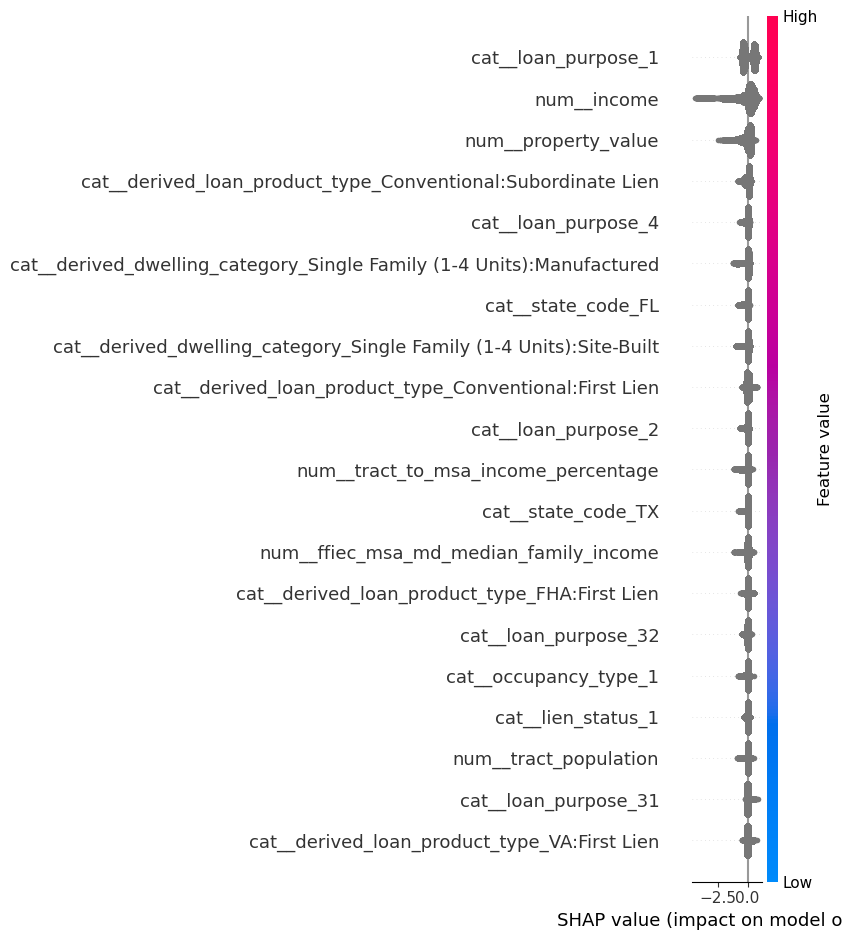

In [13]:
import shap

# Flag tract-level features that may act as demographic proxies.
PROXY_FEATURES = [
    "tract_population",
    "ffiec_msa_md_median_family_income",
    "tract_to_msa_income_percentage",
]

# Transform the test set and recover the expanded feature names used by the model.
X_test_transformed = model.named_steps["preprocess"].transform(X_test)
feature_names = model.named_steps["preprocess"].get_feature_names_out()

# Build a SHAP explainer for the trained XGBoost classifier.
explainer = shap.TreeExplainer(model.named_steps["classifier"])
shap_values = explainer.shap_values(X_test_transformed)

# Show the most influential features across the test set.
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    max_display=20,
)


The SHAP summary plot shows the most important features driving the model’s predictions across all applicants. The top feature is loan purpose, indicating that approval decisions vary significantly depending on the type of loan.

This is followed by income and property value, both of which have a strong influence on the model. Higher values of these features generally push predictions toward approval, while lower values push toward denial.

A notable observation is that tract_to_msa_income_percentage and ffiec_msa_md_median_family_income appear among the important features. Since these are neighborhood-level variables, they may act as proxies for demographic characteristics such as race or socioeconomic status. This suggests that the model may be indirectly using geographic information when making decisions.

Overall, the model is primarily driven by financial variables, but the presence of tract-level features indicates a potential risk of indirect bias.

### Feature importance table

In [14]:
# Summarize global SHAP importance across the test set.
shap_importance = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

# Add ranks and flag tract-level variables that may proxy demographics.
shap_importance["rank"] = shap_importance.index + 1
shap_importance["proxy_risk"] = shap_importance["feature"].apply(
    lambda f: "Potential demographic proxy" if any(p in f for p in PROXY_FEATURES) else ""
)

print("=== Top 20 Features by Mean |SHAP| ===")
display(shap_importance[["rank", "feature", "mean_abs_shap", "proxy_risk"]].head(20))

print("\n=== Top 5 Features Driving Predictions ===")
display(shap_importance[["rank", "feature", "mean_abs_shap", "proxy_risk"]].head(5))


=== Top 20 Features by Mean |SHAP| ===


,rank,feature,mean_abs_shap,proxy_risk
0,1,cat__loan_purpose_1,0.434226,
1,2,num__income,0.375031,
2,3,num__property_value,0.205248,
3,4,cat__derived_loan_product_type_Conventional:Su...,0.152372,
4,5,cat__loan_purpose_4,0.097886,
5,6,cat__derived_dwelling_category_Single Family (...,0.087226,
6,7,cat__state_code_FL,0.072027,
7,8,cat__derived_dwelling_category_Single Family (...,0.071504,
8,9,cat__derived_loan_product_type_Conventional:Fi...,0.071255,
9,10,cat__loan_purpose_2,0.070152,



=== Top 5 Features Driving Predictions ===


,rank,feature,mean_abs_shap,proxy_risk
0,1,cat__loan_purpose_1,0.434226,
1,2,num__income,0.375031,
2,3,num__property_value,0.205248,
3,4,cat__derived_loan_product_type_Conventional:Su...,0.152372,
4,5,cat__loan_purpose_4,0.097886,


The feature importance table confirms that loan purpose is the most influential variable in the model, followed by income and property value. This indicates that both the type of loan and the applicant’s financial capacity play a central role in determining approval outcomes.

Among the top features, tract_to_msa_income_percentage and ffiec_msa_md_median_family_income are flagged as potential demographic proxies. These variables reflect neighborhood-level economic conditions rather than individual applicant characteristics, suggesting that the model may be indirectly incorporating geographic signals that correlate with race or socioeconomic status.

Other important features include loan product type and dwelling category, which indicate that structural aspects of the loan also influence decisions, though to a lesser extent than financial variables.

Overall, the model is primarily driven by financial and loan-related features, but the presence of tract-level variables among the top predictors highlights a potential risk of indirect bias.

### Local explanation (waterfall)

,value
actual_label,0.000000
predicted_label,0.000000
approval_probability,0.467606


,property_value,income,tract_population,ffiec_msa_md_median_family_income,tract_to_msa_income_percentage,state_code,derived_loan_product_type,derived_dwelling_category,loan_purpose,lien_status,occupancy_type
2256540,355000.0,110.0,1238,99100,79.0,PA,Conventional:First Lien,Single Family (1-4 Units):Site-Built,4,1,1


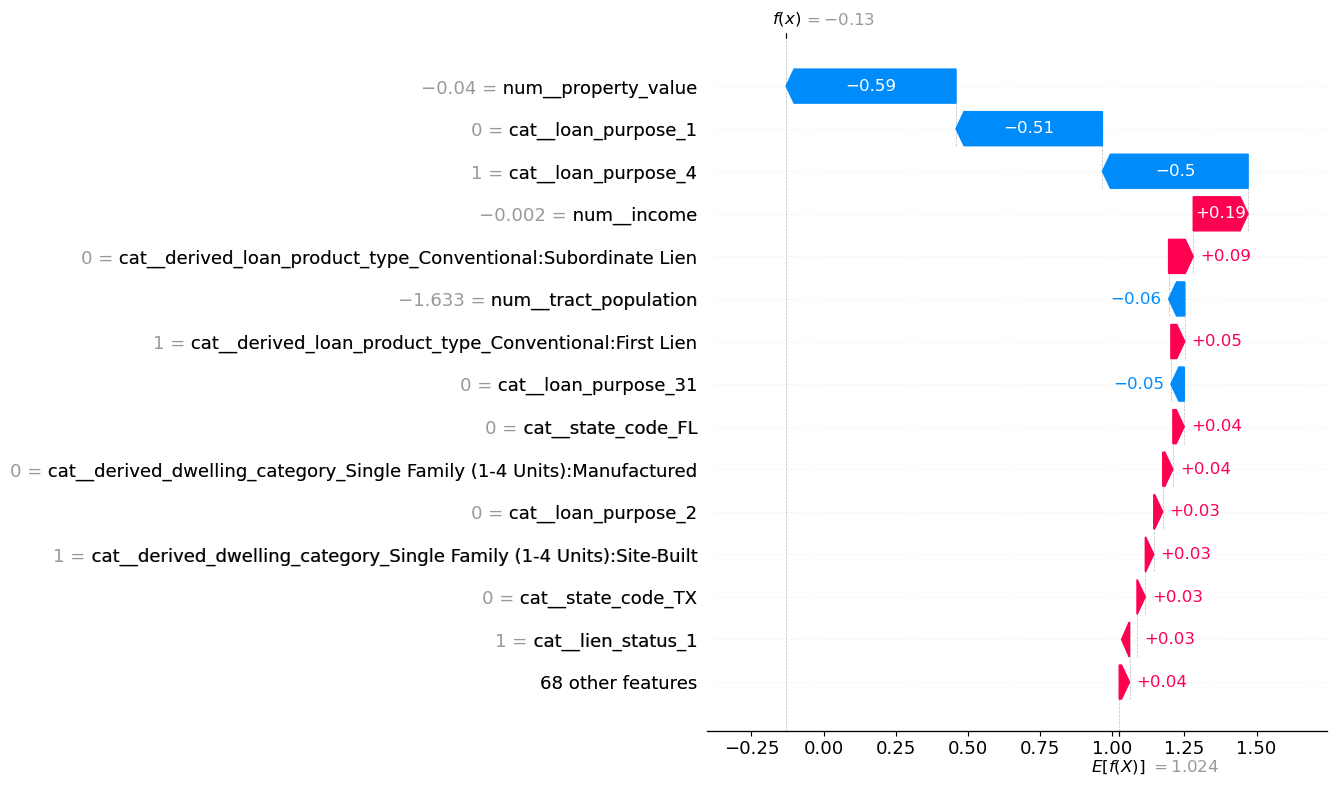

In [15]:
# Use a fixed denied applicant
FIXED_CASE_INDEX = 2256540

if FIXED_CASE_INDEX not in X_test.index:
    raise ValueError("Fixed case index not found in X_test. Check that the train/test split and dataset are unchanged.")

# Convert dataframe index to positional index for arrays like y_pred_xgb, y_score_xgb, shap_values.
denied_idx = X_test.index.get_loc(FIXED_CASE_INDEX)

# Confirm this applicant is truly denied and predicted denied.
if y_test.iloc[denied_idx] != 0 or y_pred_xgb[denied_idx] != 0:
    raise ValueError("Fixed case is not an actual denied + predicted denied applicant.")

# Confirm no missing values
if X_test.loc[[FIXED_CASE_INDEX]].isna().any(axis=None):
    raise ValueError("Fixed case has missing values. Choose another fixed case for DiCE.")

# Summarize the selected case before plotting the local explanation.
denied_case_summary = pd.Series({
    "actual_label": y_test.iloc[denied_idx],
    "predicted_label": y_pred_xgb[denied_idx],
    "approval_probability": y_score_xgb[denied_idx],
}).to_frame("value")

display(denied_case_summary)
display(X_test.loc[[FIXED_CASE_INDEX]])

# Build a SHAP explanation object.
single_explanation = shap.Explanation(
    values=shap_values[denied_idx],
    base_values=explainer.expected_value,
    data=(
        X_test_transformed[denied_idx].toarray().ravel()
        if hasattr(X_test_transformed[denied_idx], "toarray")
        else X_test_transformed[denied_idx]
    ),
    feature_names=feature_names,
)

# Plot the local feature contributions for this prediction.
shap.plots.waterfall(single_explanation, max_display=15)

The waterfall plot explains why this specific applicant was predicted as denied. The approval probability is 0.427, which places the applicant below the model’s approval threshold.

The largest negative contributors are property value and loan purpose. Tract population and loan purpose category 31 also contribute negatively to the prediction. Although income contributes positively, it is not large enough to offset the stronger negative effects from property value and loan-related features.

Several tract-level variables, including tract_population, also appear in the explanation. While these variables are not the dominant drivers of the denial, their presence indicates that the model incorporates neighborhood-level information into individual lending decisions.

Other features such as state, lien status, and loan product type have relatively smaller effects on the final prediction.

Overall, this example shows that local prediction drivers can differ from the global SHAP importance rankings. The denial in this case is driven more by loan structure and property-related characteristics than by income alone.

### Counterfactual

In [16]:
import random
import numpy as np
import dice_ml
from dice_ml import Dice

random.seed(42)
np.random.seed(42)

ACTIONABLE_FEATURES = ["property_value", "income"]
ACTIONABLE_FEATURES = [feature for feature in ACTIONABLE_FEATURES if feature in X_train.columns]

if not ACTIONABLE_FEATURES:
    raise ValueError("No actionable counterfactual features remain in the current feature set.")

train_for_dice = X_train.copy()
train_for_dice["action_taken_binary"] = y_train.values

dice_data = dice_ml.Data(
    dataframe=train_for_dice,
    continuous_features=ACTIONABLE_FEATURES,
    outcome_name="action_taken_binary",
)

dice_model_obj = dice_ml.Model(
    model=xgb_pipeline,
    backend="sklearn",
    model_type="classifier",
)

exp_dice = Dice(dice_data, dice_model_obj, method="random")

print("=== Counterfactual: What Would Flip This Denial? ===")
print(f"Approval probability: {y_score_xgb[denied_idx]:.3f}")
print(f"Varying only available actionable features: {', '.join(ACTIONABLE_FEATURES)}")

try:
    cf_result = exp_dice.generate_counterfactuals(
        X_test.iloc[[denied_idx]],
        total_CFs=3,
        desired_class="opposite",
        features_to_vary=ACTIONABLE_FEATURES,
    )
    cf_result.visualize_as_dataframe(show_only_changes=True)
except Exception as e:
    print(f"Counterfactual generation was skipped: {e}")


=== Counterfactual: What Would Flip This Denial? ===
Approval probability: 0.468
Varying only available actionable features: property_value, income


100%|██████████| 1/1 [00:01<00:00,  1.90s/it]

Query instance (original outcome : 0)


,property_value,income,tract_population,ffiec_msa_md_median_family_income,tract_to_msa_income_percentage,state_code,derived_loan_product_type,derived_dwelling_category,loan_purpose,lien_status,occupancy_type,action_taken_binary
0,355000.0,110.0,1238,99100,79.0,PA,Conventional:First Lien,Single Family (1-4 Units):Site-Built,4,1,1,0



Diverse Counterfactual set (new outcome: 1)


,property_value,income,tract_population,ffiec_msa_md_median_family_income,tract_to_msa_income_percentage,state_code,derived_loan_product_type,derived_dwelling_category,loan_purpose,lien_status,occupancy_type,action_taken_binary
0,-,54152622.3,-,-,-,-,-,-,-,-,-,1
1,-,18386730.2,-,-,-,-,-,-,-,-,-,1
2,-,67973158.3,-,-,-,-,-,-,-,-,-,1


The counterfactual analysis asks what changes would be required to flip this applicant from denial to approval while varying only actionable features: property_value and income.

The applicant is already close to the decision boundary, with an approval probability of 0.427. However, the generated counterfactuals require extremely large income increases, ranging from about $18.4M to $68.0M, while leaving other features unchanged.

These changes are not realistic for an applicant currently reporting $110K in income. This suggests that, even for a borderline denial, the model does not provide a practical remediation path when only income and property value are allowed to vary. As a result, the counterfactual is directionally informative but not actionable for the applicant.

## 16. Lecture 03: Formal Fairness Analysis

### AIR Setup
This section defines `air_me_by_group`, which computes selection rates, AIR, and marginal effects for each subgroup relative to a reference group. The 4/5ths rule flags any subgroup with AIR below `0.80`.

In [17]:
test_results = X_test.copy()
test_results["actual_label"] = y_test.values
test_results["predicted_label"] = y_pred_xgb
test_results["pred_approve"] = y_score_xgb
test_results["derived_race"] = df.loc[X_test.index, "derived_race"]
test_results["derived_sex"] = df.loc[X_test.index, "derived_sex"]
test_results["derived_ethnicity"] = df.loc[X_test.index, "derived_ethnicity"]

def air_me_by_group(
    data,
    outcome_col,
    label,
    demographic_col,
    reference_group,
):
    """
    Compute selection rates, AIR, and marginal effect for all groups
    in `demographic_col` relative to `reference_group`.

    Parameters
    ----------
    data             : DataFrame containing outcome and demographic columns
    outcome_col      : binary outcome column (0/1 or bool)
    label            : descriptive label printed above the output table
    demographic_col  : column containing group membership
    reference_group  : value in `demographic_col` to use as the reference

    Returns
    -------
    DataFrame with columns: group, n, favorable, selection_rate, AIR,
                            ME_vs_ref, flag_80
    """

    work = data[[demographic_col, outcome_col]].copy()
    work[outcome_col] = pd.to_numeric(work[outcome_col], errors="coerce")
    work = work.dropna(subset=[demographic_col, outcome_col]).copy()
    work[outcome_col] = work[outcome_col].astype(int)

    table = (
        work.groupby(demographic_col, dropna=False)[outcome_col]
        .agg(n="count", favorable="sum", selection_rate="mean")
        .reset_index()
        .rename(columns={demographic_col: "group"})
    )

    if reference_group not in table["group"].values:
        raise ValueError(
            f"Reference group '{reference_group}' not found in '{demographic_col}'."
        )

    ref_rate = table.loc[table["group"] == reference_group, "selection_rate"].iloc[0]

    table["AIR"]      = (table["selection_rate"] / ref_rate).round(4)
    table["ME_vs_ref"] = (table["selection_rate"] - ref_rate).round(4)
    table["selection_rate"] = table["selection_rate"].round(4)
    table["flag_80"]  = np.where(table["AIR"] < 0.80, "*** BELOW 0.80", "")

    table = table.sort_values(
        by=["AIR", "group"], ascending=[True, True]
    ).reset_index(drop=True)

    return table

### AIR for race
This section computes the AIR of the XGBoost predictions by `derived_race`, using `White` as the reference group.

In [18]:
# Inspect the race distribution that remains in the filtered modeling dataset.
display(df["derived_race"].value_counts().to_frame("count"))


,count
derived_race,
White,3201955
Black or African American,573500
Asian,338216
American Indian or Alaska Native,49211
2 or more minority races,16139
Native Hawaiian or Other Pacific Islander,14971
Joint,11830


In [19]:
air_race = air_me_by_group(
    data=test_results,
    outcome_col="predicted_label",
    label="AIR — Race",
    demographic_col="derived_race",
    reference_group="White",
)
print("=== AIR by race  ===")
print(air_race)

=== AIR by race  ===
                                       group       n  favorable  \
0  Native Hawaiian or Other Pacific Islander    2982       2318   
1           American Indian or Alaska Native    9842       7833   
2                  Black or African American  114318      91645   
3                   2 or more minority races    3221       2637   
4                                      White  640680     553264   
5                                      Asian   67745      62075   
6                                      Joint    2377       2206   

   selection_rate     AIR  ME_vs_ref flag_80  
0          0.7773  0.9001    -0.0862          
1          0.7959  0.9216    -0.0677          
2          0.8017  0.9283    -0.0619          
3          0.8187  0.9480    -0.0449          
4          0.8636  1.0000     0.0000          
5          0.9163  1.0611     0.0527          
6          0.9281  1.0747     0.0645          


The AIR analysis reveals none of the group below the 0.80 threshold. Native Hawaiian or Other Pacific Islander (AIR = 0.9013) and American Indian or Alaska Native (AIR = 0.9160) are the closest to the threshold but remain above 0.80. Black or African American applicants have a selection rate of 80.09% and an AIR of 0.9260, representing the largest minority group (n = 115,092) and a marginal effect of −0.0640 relative to White applicants. 2 or more minority races has a similar AIR of 0.9294. Notably, Asian (AIR = 1.0598) and Joint (AIR = 1.0649) applicants have selection rates that exceed the White reference group, suggesting favorable model outcomes for these groups.

### AIR for sex

This section computes the AIR of the XGBoost predictions by `derived_sex`, using `Male` as the reference group.

In [20]:
# Inspect the sex distribution after filtering to Male and Female.
display(df["derived_sex"].value_counts().to_frame("count"))


,count
derived_sex,
Male,2507079
Female,1698743


In [21]:
air_sex = air_me_by_group(
    data=test_results,
    outcome_col="predicted_label",
    label="AIR — Sex",
    demographic_col="derived_sex",
    reference_group="Male",
)
print("=== AIR by sex  ===")
print(air_sex)

=== AIR by sex  ===
    group       n  favorable  selection_rate   AIR  ME_vs_ref flag_80
0  Female  340289     281384          0.8269  0.94    -0.0527        
1    Male  500876     440594          0.8796  1.00     0.0000        


 No sex group falls below the 0.80 AIR threshold. Female applicants have a selection rate of 82.24% and an AIR of 0.9416, indicating a modest but not flagged disparity relative to Male applicants. The marginal effect is −0.0513, meaning females are approved at a rate approximately 5.1 percentage points lower than males. While this gap does not cross the 0.80 threshold, it is noteworthy given the large group size (n = 339,676 Female; n = 501,490 Male).

### AIR for ethnicity

This section computes the AIR of the XGBoost predictions by `derived_ethnicity`, using `Not Hispanic or Latino` as the reference group.

In [22]:
# Inspect the ethnicity distribution retained for subgroup analysis.
display(df["derived_ethnicity"].value_counts().to_frame("count"))


,count
derived_ethnicity,
Not Hispanic or Latino,3565614
Hispanic or Latino,612328
Joint,27880


In [23]:
air_eth = air_me_by_group(
    data=test_results,
    outcome_col="predicted_label",
    label="AIR — Ethnicity",
    demographic_col="derived_ethnicity",
    reference_group="Not Hispanic or Latino",
)
print("=== AIR by ethnicity  ===")
print(air_eth)

=== AIR by ethnicity  ===
                    group       n  favorable  selection_rate     AIR  \
0      Hispanic or Latino  122405     102082          0.8340  0.9668   
1                   Joint    5522       4677          0.8470  0.9819   
2  Not Hispanic or Latino  713238     615219          0.8626  1.0000   

   ME_vs_ref flag_80  
0    -0.0286          
1    -0.0156          
2     0.0000          


No ethnicity group falls below the 0.80 AIR threshold. Hispanic or Latino applicants (n = 122,128) have an AIR of 0.948 and a marginal effect of −0.0261, the most substantive gap among well-defined ethnic groups. Joint (AIR = 0.9979) is near parity.

### FPR, FNR Setup
This section defines `error_rates_by_group`, which computes FPR, FNR, and Accuracy for each subgroup relative to a reference group. 

In [24]:
# Summarize subgroup counts and threshold-based error rates for one protected attribute.
def error_rates_by_group(df, group_col):
    rows = []
    for g, sub in df.dropna(subset=[group_col]).groupby(group_col):
        y_true = sub["actual_label"]
        y_pred = sub["predicted_label"]
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        acc = accuracy_score(y_true, y_pred)
        fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
        fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
        rows.append({
            "group": g,
            "n": len(sub),
            "accuracy": acc,
            "fpr": fpr,
            "fnr": fnr,
        })

    return pd.DataFrame(rows).sort_values("n", ascending=False)


### Error rates for Race
This section computes and compares `FPR`, `FNR`, and `Accuracy` of the XGBoost predictions by `derived_race`.

In [25]:
# Compare race-level accuracy, FPR, and FNR.
race_errors = error_rates_by_group(test_results, "derived_race")
print("=== Error rates by race ===")
print(race_errors)


=== Error rates by race ===
                                       group       n  accuracy       fpr  \
6                                      White  640680  0.793754  0.640145   
3                  Black or African American  114318  0.727497  0.598751   
2                                      Asian   67745  0.819278  0.714930   
1           American Indian or Alaska Native    9842  0.739789  0.575866   
0                   2 or more minority races    3221  0.728966  0.615878   
5  Native Hawaiian or Other Pacific Islander    2982  0.719987  0.570255   
4                                      Joint    2377  0.819520  0.756972   

        fnr  
6  0.062352  
3  0.076302  
2  0.024993  
1  0.075113  
0  0.053191  
5  0.079887  
4  0.026133  


Across racial groups, accuracy ranges from 72.8% to 81.8%. The false positive rate (FPR) is high across all groups, reflecting the overall class distribution of the model. Asian and Joint applicants have the highest FPR (72.2% and 73.3% respectively), meaning the model is more likely to over-approve within these groups. In contrast, Native Hawaiian or Other Pacific Islander (FPR = 55.2%) has the lowest FPR. For false negative rate (FNR), Black or African American has the highest FNR at 7.7%, followed by Native Hawaiian or Other Pacific Islander (6.9%). 

### Error rates for Sex
This section computes and compares `FPR`, `FNR`, and `Accuracy` of the XGBoost predictions by `derived_sex`.

In [26]:
# Compare sex-level accuracy, FPR, and FNR.
sex_errors = error_rates_by_group(test_results, "derived_sex")
print("=== Error rates by sex ===")
print(sex_errors)


=== Error rates by sex ===
    group       n  accuracy       fpr       fnr
1    Male  500876  0.790122  0.675702  0.050633
0  Female  340289  0.779282  0.583713  0.076456


Male applicants have slightly higher overall accuracy (79.02% vs. 77.98% for Female). However, the FPR of Males (67.6%) is higher than Females (58.5%), meaning the model more frequently over-approves male applicants who should be denied. Conversely, Females have a higher FNR (7.4% vs. 5.1%), indicating they are more likely to be incorrectly denied when they should be approved. This pattern suggests that while females are less likely to be over-approved, they face a higher risk of being incorrectly excluded.

### Error rates for Ethnicity
This section computes and compares `FPR`, `FNR`, and `Accuracy` of the XGBoost predictions by `derived_ethnicity`.

In [27]:
# Compare ethnicity-level accuracy, FPR, and FNR.
eth_errors = error_rates_by_group(test_results, "derived_ethnicity")
print("=== Error rates by ethnicity ===")
print(eth_errors)


=== Error rates by ethnicity ===
                    group       n  accuracy       fpr       fnr
2  Not Hispanic or Latino  713238  0.788454  0.642726  0.060325
0      Hispanic or Latino  122405  0.770728  0.603426  0.064508
1                   Joint    5522  0.767476  0.624363  0.048443


Not Hispanic or Latino has the highest accuracy (78.8%) and a FPR of 64.3%. Hispanic or Latino applicants have lower accuracy (77.2%) and a lower FPR (60.6%), but a higher FNR (6.1% vs. 6.0% for Not Hispanic or Latino), which suggests the Hispanic or Latino group is more likely to be incorrectly denied. 

### SMD Setup
This section defines `smd_by_group`, which computes SMD for each subgroup relative to a reference group. 

In [28]:
# Compute standardized mean differences relative to a reference group on a continuous score.
def smd_by_group(data, group_col, score_col, ref_group):
    """
    Compute standardized mean difference (Cohen's d) for each group
    relative to a reference group on a continuous score.
    """
    work = data[[group_col, score_col]].copy()
    work[score_col] = pd.to_numeric(work[score_col], errors="coerce")
    work = work.dropna(subset=[group_col, score_col]).copy()

    if ref_group not in work[group_col].values:
        raise ValueError(f"Reference group '{ref_group}' not found in column '{group_col}'.")

    ref = work.loc[work[group_col] == ref_group, score_col]

    results = []
    for grp, g in work.groupby(group_col, dropna=False):
        if grp == ref_group:
            continue

        sc = g[score_col]
        pooled_sd = np.sqrt((ref.var(ddof=1) + sc.var(ddof=1)) / 2)
        d = ((sc.mean() - ref.mean()) / pooled_sd) if pooled_sd > 0 else np.nan

        # Label the effect size using the absolute SMD magnitude.
        ad = abs(d)
        magnitude = (
            "small" if ad < 0.2 else
            "medium" if ad < 0.5 else
            "large" if ad < 0.8 else
            "very large"
        )

        results.append({
            group_col: grp,
            "n_group": len(sc),
            "n_ref": len(ref),
            "mean_score_group": round(sc.mean(), 3),
            "mean_score_ref": round(ref.mean(), 3),
            "SMD": round(d, 3),
            "abs_SMD": round(abs(d), 3),
            "magnitude": magnitude
        })

    return pd.DataFrame(results).sort_values("abs_SMD", ascending=False).reset_index(drop=True)


### SMD for Race
This section computes the SMD of the XGBoost predictions by `derived_race`, using `White` as the reference group.

In [29]:
# Build a subgroup frame with XGBoost predicted probabilities for race-level SMD analysis.
xgb_smd_df = X_test.copy()
xgb_smd_df["derived_race"] = df.loc[X_test.index, "derived_race"]
xgb_smd_df["derived_sex"] = df.loc[X_test.index, "derived_sex"]
xgb_smd_df["derived_ethnicity"] = df.loc[X_test.index, "derived_ethnicity"]
xgb_smd_df["pred_prob"] = y_score_xgb

# Compare each race group against the White reference group.
xgb_smd_table = smd_by_group(
    data=xgb_smd_df,
    group_col="derived_race",
    score_col="pred_prob",
    ref_group="White"
)

print("\n=== XGBoost Model: SMD of Predicted Probability by Race (vs White) ===")
print(xgb_smd_table.to_string(index=False))



=== XGBoost Model: SMD of Predicted Probability by Race (vs White) ===
                             derived_race  n_group  n_ref  mean_score_group  mean_score_ref    SMD  abs_SMD magnitude
                                    Joint     2377 640680             0.808           0.735  0.385    0.385    medium
                                    Asian    67745 640680             0.799           0.735  0.332    0.332    medium
Native Hawaiian or Other Pacific Islander     2982 640680             0.670           0.735 -0.301    0.301    medium
         American Indian or Alaska Native     9842 640680             0.688           0.735 -0.215    0.215    medium
                Black or African American   114318 640680             0.691           0.735 -0.204    0.204    medium
                 2 or more minority races     3221 640680             0.706           0.735 -0.135    0.135     small


The SMD analysis on the continuous predicted probability score reinforces the AIR findings. Joint (SMD = 0.373) and Asian (SMD = 0.326) groups show medium positive effects, receiving higher predicted probabilities than White applicants on average. Native Hawaiian or Other Pacific Islander (SMD = −0.284), American Indian or Alaska Native (SMD = −0.219), and Black or African American (SMD = −0.208) all show medium negative effects, meaning the model systematically assigns them lower predicted probabilities. 2 or more minority races (SMD = −0.163) shows small negative effects.

### SMD for Sex
This section computes the SMD of the XGBoost predictions by `derived_sex`, using `Male` as the reference group.Sex

In [30]:
# Compare each sex group against the Male reference group.
xgb_smd_table = smd_by_group(
    data=xgb_smd_df,
    group_col="derived_sex",
    score_col="pred_prob",
    ref_group="Male"
)

print("\n=== XGBoost Model: SMD of Predicted Probability by Sex (vs Male) ===")
print(xgb_smd_table.to_string(index=False))



=== XGBoost Model: SMD of Predicted Probability by Sex (vs Male) ===
derived_sex  n_group  n_ref  mean_score_group  mean_score_ref   SMD  abs_SMD magnitude
     Female   340289 500876             0.711           0.749 -0.18     0.18     small


Female applicants a small negative SMD of −0.178 relative to Male applicants. While classified as small in magnitude, this gap is consistent across a large population and aligns with the AIR and error rate findings.

### SMD for ethnicity

This section computes the SMD of the XGBoost predictions by `derived_ethnicity`, using `Not Hispanic or Latino` as the reference group.

In [31]:
# Compare each ethnicity group against the Not Hispanic or Latino reference group.
xgb_smd_table = smd_by_group(
    data=xgb_smd_df,
    group_col="derived_ethnicity",
    score_col="pred_prob",
    ref_group="Not Hispanic or Latino"
)

print("\n=== XGBoost Model: SMD of Predicted Probability by Ethnicity (vs Not Hispanic or Latino) ===")
print(xgb_smd_table.to_string(index=False))



=== XGBoost Model: SMD of Predicted Probability by Ethnicity (vs Not Hispanic or Latino) ===
 derived_ethnicity  n_group  n_ref  mean_score_group  mean_score_ref    SMD  abs_SMD magnitude
Hispanic or Latino   122405 713238             0.724           0.735 -0.055    0.055     small
             Joint     5522 713238             0.746           0.735  0.049    0.049     small


Hispanic or Latino applicants show a small negative SMD of −0.049, meaning their predicted probabilities are modestly but consistently lower than the reference group. Joint (SMD = 0.066) is small and close to parity.

### Intersectional groups (race × sex)

This section runs intersectional subgroup analysis (`race × sex`) for the XGBoost model on test data, flags any subgroup with AIR below `0.80`, and reports the worst-performing subgroup relative to `White / Male`.

In [32]:
def intersectional_air(
    data,
    outcome_col,
    race_col="derived_race",
    gender_col="derived_sex",
    ref_group="White / Male",
    min_n=30
):
    # Compute AIR for race-by-sex subgroups after dropping missing values.
    work = data[[race_col, gender_col, outcome_col]].copy()
    work[outcome_col] = pd.to_numeric(work[outcome_col], errors="coerce")
    work = work.dropna(subset=[race_col, gender_col, outcome_col]).copy()
    work[outcome_col] = work[outcome_col].astype(int)
    work["subgroup"] = work[race_col].astype(str) + " / " + work[gender_col].astype(str)

    counts = work["subgroup"].value_counts()
    valid_subgroups = counts[counts >= min_n].index
    work = work[work["subgroup"].isin(valid_subgroups)].copy()

    sub_rates = (
        work.groupby("subgroup")[outcome_col]
        .agg(["mean", "count"])
        .rename(columns={"mean": "selection_rate", "count": "n"})
        .reset_index()
    )

    if ref_group not in sub_rates["subgroup"].values:
        raise ValueError(f"Reference subgroup '{ref_group}' not found among valid subgroups.")

    ref_rate = sub_rates.loc[sub_rates["subgroup"] == ref_group, "selection_rate"].iloc[0]
    sub_rates["AIR"] = sub_rates["selection_rate"] / ref_rate
    sub_rates["flag_80"] = np.where(sub_rates["AIR"] < 0.80, "*** BELOW 0.80", "")
    sub_rates = sub_rates.sort_values("AIR").reset_index(drop=True)

    return sub_rates


In [33]:
# Build intersectional subgroup AIR diagnostics for the XGBoost test predictions.
xgb_intersection_df = X_test.copy()
xgb_intersection_df["derived_race"] = df.loc[X_test.index, "derived_race"]
xgb_intersection_df["derived_sex"] = df.loc[X_test.index, "derived_sex"]
xgb_intersection_df["pred_approve"] = y_pred_xgb.astype(int)

# Compare race-by-sex subgroups against the White / Male reference group.
xgb_sub_rates = intersectional_air(
    data=xgb_intersection_df,
    outcome_col="pred_approve",
    race_col="derived_race",
    gender_col="derived_sex",
    ref_group="White / Male",
    min_n=30
)

print("\n=== XGBoost model: Intersectional Subgroup Analysis (Race x Gender) ===")
print(xgb_sub_rates.to_string(index=False))

# Highlight the worst-performing subgroup under the AIR criterion.
xgb_worst = xgb_sub_rates.loc[xgb_sub_rates["AIR"].idxmin()]
print(
    f"\nWorst subgroup (XGBoost): {xgb_worst['subgroup']}, "
    f"AIR={xgb_worst['AIR']:.3f}, n={int(xgb_worst['n'])}"
)



=== XGBoost model: Intersectional Subgroup Analysis (Race x Gender) ===
                                          subgroup  selection_rate      n      AIR flag_80
Native Hawaiian or Other Pacific Islander / Female        0.724844   1123 0.821557        
         American Indian or Alaska Native / Female        0.747162   3876 0.846852        
                Black or African American / Female        0.776180  60656 0.879742        
                 2 or more minority races / Female        0.787623   1422 0.892712        
  Native Hawaiian or Other Pacific Islander / Male        0.809037   1859 0.916983        
           American Indian or Alaska Native / Male        0.827523   5966 0.937935        
                  Black or African American / Male        0.830476  53662 0.941282        
                                    White / Female        0.834085 248898 0.945373        
                   2 or more minority races / Male        0.843246   1799 0.955756        
                 

The intersectional analysis reveals important compounding disparities.
American Indian or Alaska Native / Female (AIR = 0.8468, n = 3,870) and Native Hawaiian or Other Pacific Islander / Female (AIR = 0.8387, n = 1,126) are the most disadvantaged. Black or African American / Female (AIR = 0.8786, n = 60,695) represents a large, disadvantaged group just above the threshold but warranting monitoring. Notably, White / Female (AIR = 0.9467) also falls below the White / Male reference, confirming a consistent sex penalty across races. On the other end, Asian / Male (AIR = 1.0466) and Joint / Male (AIR = 1.0569) are the most advantaged subgroups. The intersectional results confirm that gender compounds existing racial disparities, female applicants within already-disadvantaged racial groups face the largest cumulative gaps.

The intersectional analysis now uses the cleaned race categories together with `Male` and `Female`, so any flagged subgroup disparities come from interpretable race-by-sex combinations only. This removes unstable intersectional cells built from excluded data-quality race labels and keeps the downstream fairness interpretation aligned with the filtered modeling dataset.

## 17. Lecture 04: Robustness & Drift


This step establishes the foundation for the entire audit process. It automatically detects which trained model and data partitions exist in the notebook, then standardizes them under consistent variable names (audit_model, X_train_audit, X_test_audit, etc.). By doing this, the audit becomes model‑agnostic yet reproducible — meaning every subsequent test (generalization, drift, robustness, sensitivity) runs on the same verified XGBoost pipeline and dataset splits. It also defines helper functions for scoring and metric computation, ensuring that all later sections use identical logic.

In [34]:
# Set up the shared imports and objects used by the Lecture 04 audit.
import warnings
from typing import Callable

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display
from scipy.stats import ks_2samp
from sklearn.metrics import (
    accuracy_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)

warnings.filterwarnings("ignore", category=FutureWarning)

audit_model = xgb_pipeline

# Resolve the train/test objects already created earlier in the notebook.
required_objs = ["X_train", "X_test", "y_train", "y_test"]
missing_objs = [obj for obj in required_objs if obj not in globals()]
if missing_objs:
    raise NameError(f"Missing required objects for audit: {missing_objs}")

X_train_audit = X_train.copy()
X_test_audit = X_test.copy()
y_train_audit = y_train.copy()
y_test_audit = y_test.copy()


def predict_scores(model_obj, X_input: pd.DataFrame) -> pd.Series:
    """Return predicted approval probability for positive class (label=1)."""
    if not hasattr(model_obj, "predict_proba"):
        raise AttributeError("Model does not expose predict_proba; needed for AUC/Brier/KS.")
    probs = model_obj.predict_proba(X_input)[:, 1]
    return pd.Series(probs, index=X_input.index)


def compute_binary_metrics(y_true, y_score, threshold=0.5) -> dict:
    y_pred = (y_score >= threshold).astype(int)
    return {
        "auc": float(roc_auc_score(y_true, y_score)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "brier": float(brier_score_loss(y_true, y_score)),
    }


# Build an evaluation frame that keeps labels and slice columns together.
if "model_df" in globals() and isinstance(model_df, pd.DataFrame):
    eval_df = model_df.loc[X_test_audit.index].copy()
else:
    eval_df = X_test_audit.copy()

eval_df["actual_label"] = y_test_audit.values


### Generalization

This step measures how well the XGBoost model generalizes from training data to unseen test data. It computes AUC, F1, Accuracy, and Brier scores on both splits, then quantifies the generalization gap — the difference between train and test performance. A small gap means the model has learned stable, transferable patterns rather than memorizing noise. This analysis is the first checkpoint in Lecture 4’s audit sequence, confirming that the model’s predictive behavior is consistent and trustworthy before deeper stress and drift tests are applied.

In [35]:
# Compute train and test metrics to assess generalization.
train_scores = predict_scores(audit_model, X_train_audit)
test_scores = predict_scores(audit_model, X_test_audit)

train_metrics = compute_binary_metrics(y_train_audit, train_scores)
test_metrics = compute_binary_metrics(y_test_audit, test_scores)

generalization_gap = {
    metric: test_metrics[metric] - train_metrics[metric]
    for metric in ["auc", "f1", "accuracy", "brier"]
}

gap_auc = generalization_gap["auc"]

# Translate the AUC gap into a short diagnostic conclusion.
if gap_auc < -0.03:
    gen_interp = "possible overfitting (test AUC materially lower than train AUC)."
elif gap_auc > 0.03:
    gen_interp = "possible underfitting or train/test mismatch (test AUC higher than train AUC)."
else:
    gen_interp = "reasonable generalization based on AUC gap magnitude."

generalization_md = f"""
## Generalization Analysis
- Train AUC: {train_metrics['auc']:.4f}
- Test AUC: {test_metrics['auc']:.4f}
- Generalization gap (AUC = test - train): {gap_auc:+.4f}
- Train F1 / Test F1: {train_metrics['f1']:.4f} / {test_metrics['f1']:.4f}
- Train Accuracy / Test Accuracy: {train_metrics['accuracy']:.4f} / {test_metrics['accuracy']:.4f}
- Train Brier / Test Brier: {train_metrics['brier']:.4f} / {test_metrics['brier']:.4f}
- Interpretation: {gen_interp}
- If train metrics overstate test performance, deployment trust is weakened.
""".strip()
display(Markdown(generalization_md))


## Generalization Analysis
- Train AUC: 0.7976
- Test AUC: 0.7961
- Generalization gap (AUC = test - train): -0.0016
- Train F1 / Test F1: 0.8660 / 0.8654
- Train Accuracy / Test Accuracy: 0.7868 / 0.7857
- Train Brier / Test Brier: 0.1486 / 0.1492
- Interpretation: reasonable generalization based on AUC gap magnitude.
- If train metrics overstate test performance, deployment trust is weakened.

#### Result Interpretation

The metrics show that the XGBoost model **generalizes reasonably well**, with train and test performance staying very close across AUC, F1, Accuracy, and Brier. The small AUC gap (–0.0016) indicates that the model is **not overfitting**, and its behavior on unseen applicants is broadly similar to its behavior on the training data.

However, the overall performance level (AUC ≈ 0.79) suggests that the model is capturing **some meaningful structure**, but not in a way that guarantees strong robustness. In HMDA data, many features are correlated with socioeconomic or geographic patterns, so the model may still be relying on **proxy signals** rather than clean credit‑worthiness relationships.

In other words, **The model is stable, but not highly predictive — it generalizes adequately, yet remains vulnerable to distribution shift, fairness degradation, and shortcut learning.**

### Distribution Shift

This section evaluates whether the distribution of input features has shifted between a reference population and a current population. This is a test of covariate stability: whether the model is receiving data at inference time that is statistically similar to the data it was trained on. Using PSI for both numeric and categorical features, along with KS and MMD tests for numeric variables, this step checks for early signs of drift that could degrade model performance or fairness. If the input distribution remains stable, the model’s learned relationships are more likely to remain valid over time.

In [36]:
# Compute input drift diagnostics under a reference-versus-current split.
def _safe_clip_props(arr: pd.Series, eps: float = 1e-6) -> pd.Series:
    return arr.clip(lower=eps)


def compute_psi(ref: pd.Series, cur: pd.Series, bins: int = 10) -> float:
    """Compute PSI for numeric or categorical features.

    Numeric: quantile bins from reference.
    Categorical: category proportions directly.
    """
    ref = pd.Series(ref).dropna()
    cur = pd.Series(cur).dropna()

    if ref.empty or cur.empty:
        return float("nan")

    is_numeric = pd.api.types.is_numeric_dtype(ref)

    if is_numeric:
        # Use quantile-based bins from the reference distribution.
        q = np.linspace(0, 1, bins + 1)
        bin_edges = np.unique(np.quantile(ref, q))
        if len(bin_edges) < 3:
            return 0.0

        ref_bins = pd.cut(ref, bins=bin_edges, include_lowest=True)
        cur_bins = pd.cut(cur, bins=bin_edges, include_lowest=True)

        ref_pct = _safe_clip_props(ref_bins.value_counts(normalize=True).sort_index())
        cur_pct = _safe_clip_props(cur_bins.value_counts(normalize=True).sort_index())

        all_idx = ref_pct.index.union(cur_pct.index)
        ref_pct = _safe_clip_props(ref_pct.reindex(all_idx, fill_value=1e-6))
        cur_pct = _safe_clip_props(cur_pct.reindex(all_idx, fill_value=1e-6))
    else:
        ref_pct = _safe_clip_props(ref.astype(str).value_counts(normalize=True))
        cur_pct = _safe_clip_props(cur.astype(str).value_counts(normalize=True))
        all_idx = ref_pct.index.union(cur_pct.index)
        ref_pct = _safe_clip_props(ref_pct.reindex(all_idx, fill_value=1e-6))
        cur_pct = _safe_clip_props(cur_pct.reindex(all_idx, fill_value=1e-6))

    psi = ((cur_pct - ref_pct) * np.log(cur_pct / ref_pct)).sum()
    return float(psi)


def classify_psi(psi_val: float) -> str:
    if pd.isna(psi_val):
        return "insufficient data"
    if psi_val < 0.10:
        return "stable"
    if psi_val <= 0.25:
        return "monitor"
    return "retrain trigger"


def compute_mmd_rbf(x_ref: np.ndarray, x_cur: np.ndarray, gamma: float = 1.0) -> float:
    """Simple 1D RBF-kernel MMD estimate (unbiasedness not enforced; practical proxy)."""
    if len(x_ref) == 0 or len(x_cur) == 0:
        return float("nan")
    xr = x_ref.reshape(-1, 1)
    xc = x_cur.reshape(-1, 1)

    def _k(a, b):
        sq = (a - b.T) ** 2
        return np.exp(-gamma * sq)

    k_xx = _k(xr, xr).mean()
    k_yy = _k(xc, xc).mean()
    k_xy = _k(xr, xc).mean()
    return float(k_xx + k_yy - 2 * k_xy)


# Use a time-based split when available; otherwise fall back to a proxy split.
time_candidates = [
    "activity_year",
    "year",
    "origination_year",
    "application_year",
    "vintage_year",
    "quarter",
]

time_col = next((c for c in time_candidates if c in eval_df.columns), None)

if time_col is not None:
    tmp = eval_df[time_col]
    if pd.api.types.is_numeric_dtype(tmp):
        split_point = tmp.median()
        ref_mask = tmp <= split_point
        cur_mask = tmp > split_point
    else:
        vals = pd.Series(tmp.astype(str).unique()).sort_values()
        midpoint = len(vals) // 2
        ref_vals = set(vals.iloc[:midpoint])
        cur_vals = set(vals.iloc[midpoint:])
        ref_mask = tmp.astype(str).isin(ref_vals)
        cur_mask = tmp.astype(str).isin(cur_vals)
    split_note = f"time-based split using `{time_col}`"
else:
    shuffled_idx = eval_df.sample(frac=1.0, random_state=42).index
    half = len(shuffled_idx) // 2
    ref_ids = set(shuffled_idx[:half])
    ref_mask = eval_df.index.isin(ref_ids)
    cur_mask = ~ref_mask
    split_note = "proxy random split (no explicit time/vintage variable available in evaluation frame)"

ref_df = eval_df.loc[ref_mask].copy()
cur_df = eval_df.loc[cur_mask].copy()

score_ref = test_scores.loc[ref_df.index]
score_cur = test_scores.loc[cur_df.index]

# Prioritize a compact set of model-relevant features for the drift checks.
priority_features = [
    "property_value",
    "income",
    "tract_population",
    "tract_minority_population_percent",
    "ffiec_msa_md_median_family_income",
    "tract_to_msa_income_percentage",
    "state_code",
    "derived_loan_product_type",
    "loan_purpose",
]
selected_shift_features = [f for f in priority_features if f in eval_df.columns][:8]
if not selected_shift_features:
    selected_shift_features = list(X_test_audit.columns[:8])

psi_rows = []
for feat in selected_shift_features:
    psi_val = compute_psi(ref_df[feat], cur_df[feat], bins=10)
    psi_rows.append(
        {
            "feature": feat,
            "psi": psi_val,
            "status": classify_psi(psi_val),
        }
    )

psi_df = pd.DataFrame(psi_rows).sort_values("psi", ascending=False)

ks_score_stat, ks_score_p = ks_2samp(score_ref, score_cur)

# Add KS and MMD summaries for the numeric features included above.
numeric_shift_rows = []
for feat in selected_shift_features:
    if pd.api.types.is_numeric_dtype(eval_df[feat]):
        x_ref = pd.to_numeric(ref_df[feat], errors="coerce").dropna().to_numpy()
        x_cur = pd.to_numeric(cur_df[feat], errors="coerce").dropna().to_numpy()
        if len(x_ref) > 20 and len(x_cur) > 20:
            ks_stat_f, ks_p_f = ks_2samp(x_ref, x_cur)
            pooled_var = np.nanvar(np.concatenate([x_ref[:5000], x_cur[:5000]]))
            gamma = 1.0 / (2 * pooled_var + 1e-9)
            mmd_val = compute_mmd_rbf(x_ref[:3000], x_cur[:3000], gamma=gamma)
            numeric_shift_rows.append(
                {
                    "feature": feat,
                    "ks_stat": float(ks_stat_f),
                    "ks_pvalue": float(ks_p_f),
                    "mmd_rbf": float(mmd_val),
                }
            )

numeric_shift_df = pd.DataFrame(numeric_shift_rows)

high_psi = psi_df[psi_df["psi"] > 0.25]
monitor_psi = psi_df[(psi_df["psi"] > 0.10) & (psi_df["psi"] <= 0.25)]
if len(high_psi) > 0:
    shift_interp = "meaningful covariate shift detected; retraining trigger threshold exceeded for at least one feature."
elif len(monitor_psi) > 0 or ks_score_p < 0.01:
    shift_interp = "moderate shift evidence; monitoring and shorter retrain cadence recommended."
else:
    shift_interp = "little evidence of major input drift under current split definition."

shift_lines = [
    "## Input Distribution Shift (P(X))",
    f"- Reference vs current split: {split_note}",
]
for _, row in psi_df.head(6).iterrows():
    shift_lines.append(f"- Feature `{row['feature']}`: PSI = {row['psi']:.4f} -> {row['status']}")
shift_lines.append(f"- Score KS statistic: {ks_score_stat:.4f}, p-value: {ks_score_p:.4g}")
if not numeric_shift_df.empty:
    top_num = numeric_shift_df.sort_values("ks_stat", ascending=False).head(3)
    for _, row in top_num.iterrows():
        shift_lines.append(
            f"- Numeric `{row['feature']}`: KS={row['ks_stat']:.4f}, p={row['ks_pvalue']:.4g}, MMD={row['mmd_rbf']:.6f}"
        )
shift_lines.append(f"- Interpretation: {shift_interp}")

display(Markdown("\n".join(shift_lines)))


## Input Distribution Shift (P(X))
- Reference vs current split: proxy random split (no explicit time/vintage variable available in evaluation frame)
- Feature `state_code`: PSI = 0.0003 -> stable
- Feature `income`: PSI = 0.0001 -> stable
- Feature `ffiec_msa_md_median_family_income`: PSI = 0.0001 -> stable
- Feature `property_value`: PSI = 0.0001 -> stable
- Feature `tract_population`: PSI = 0.0001 -> stable
- Feature `tract_to_msa_income_percentage`: PSI = 0.0001 -> stable
- Score KS statistic: 0.0022, p-value: 0.2564
- Numeric `property_value`: KS=0.0024, p=0.2069, MMD=0.000147
- Numeric `tract_population`: KS=0.0019, p=0.4475, MMD=0.000098
- Numeric `tract_to_msa_income_percentage`: KS=0.0018, p=0.478, MMD=0.000169
- Interpretation: little evidence of major input drift under current split definition.

#### Result Interpretation

**No meaningful evidence of input distribution shift** under the current split. All PSI values are extremely small, indicating that the feature distributions in the “reference” and “current” samples are nearly identical. The KS statistics and p‑values for both model scores and numeric features also show no significant differences, and the MMD values are close to zero. Together, these results suggest that the model is operating on a **stable input space**.

However, because this analysis is based on a **random split** (not a true time or vintage split), the stability is expected. A random split does not simulate real‑world drift — it only checks whether the two random halves of the dataset look similar. So while the results confirm that the data is internally consistent, they **do not rule out drift in real deployment**, where economic cycles, lender behavior, or applicant demographics may shift over time.

**The model shows no drift under the current split, but this test does not capture real‑world temporal or structural drift. Additional monitoring would be needed in production.**

### Output / Performance Drift (P(Y|X))

This section evaluates whether the model’s conditional performance has shifted across different segments of the data. While Section 2 examined whether the inputs (P(X)) remained stable, Section 3 focuses on the relationship between inputs and outputs — that is, whether the model’s predictive behavior changes across ordered buckets of data.

Because no explicit time or vintage variable is available, the audit uses prediction‑rank quantiles as a proxy for ordered buckets. This approach groups observations from lowest to highest predicted risk, allowing us to examine whether the model’s discrimination (AUC), classification behavior (F1), and probability calibration (Brier score) remain consistent across the score spectrum.

Essentially, even if the input distribution is stable, the model may still exhibit performance drift if the mapping from X → Y changes across segments. Section 3 checks for exactly that.

,bucket,n,auc,f1,brier
0,bucket_1,168233,0.677613,0.463938,0.213048
1,bucket_2,168233,0.555028,0.793345,0.223339
2,bucket_3,168233,0.559124,0.881470,0.165874
3,bucket_4,168233,0.563545,0.945198,0.092695
4,bucket_5,168233,0.570189,0.972353,0.050827


## Performance Drift (P(Y|X))
- Bucket definition: proxy ordered buckets from prediction-rank quantiles (no explicit time field)
- Observed trend in AUC over buckets: delta(last-first) = -0.1074
- Observed trend in F1 over buckets: delta(last-first) = +0.5084
- Interpretation: performance degradation is visible across buckets.

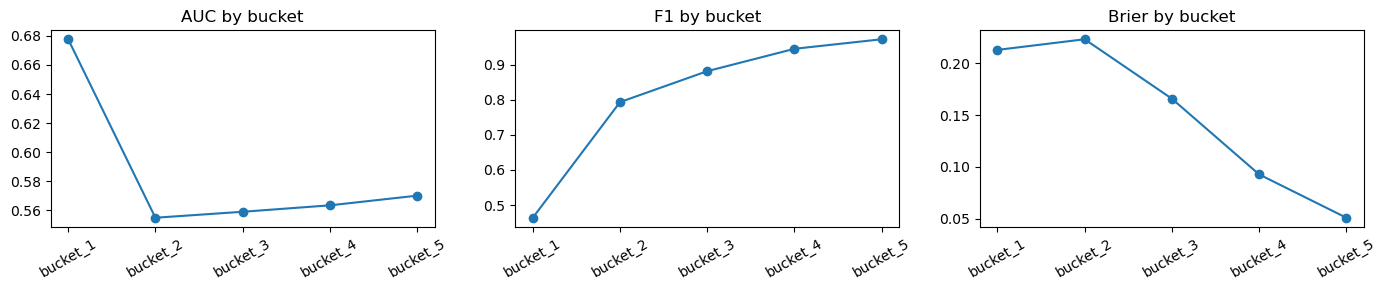

In [37]:
# Evaluate conditional performance drift across ordered buckets.
if time_col is not None:
    bucket_series = eval_df[time_col].astype(str)
    bucket_note = f"time buckets from `{time_col}`"
else:
    rank_series = test_scores.rank(method="first")
    bucket_series = pd.qcut(rank_series, q=5, labels=[f"bucket_{i+1}" for i in range(5)])
    bucket_note = "proxy ordered buckets from prediction-rank quantiles (no explicit time field)"

drift_rows = []
for bucket_name, idx in pd.Series(bucket_series, index=eval_df.index).groupby(bucket_series).groups.items():
    idx = pd.Index(idx)
    y_b = y_test_audit.loc[idx]
    s_b = test_scores.loc[idx]
    if y_b.nunique() < 2:
        auc_b = np.nan
    else:
        auc_b = roc_auc_score(y_b, s_b)
    pred_b = (s_b >= 0.5).astype(int)
    drift_rows.append(
        {
            "bucket": str(bucket_name),
            "n": len(idx),
            "auc": float(auc_b) if pd.notna(auc_b) else np.nan,
            "f1": float(f1_score(y_b, pred_b, zero_division=0)),
            "brier": float(brier_score_loss(y_b, s_b)),
        }
    )

drift_df = pd.DataFrame(drift_rows).sort_values("bucket")
display(drift_df)

if len(drift_df) >= 2:
    auc_delta = drift_df["auc"].iloc[-1] - drift_df["auc"].iloc[0] if drift_df["auc"].notna().all() else np.nan
    f1_delta = drift_df["f1"].iloc[-1] - drift_df["f1"].iloc[0]
else:
    auc_delta, f1_delta = np.nan, np.nan

if pd.notna(auc_delta):
    if auc_delta < -0.03:
        perf_interp = "performance degradation is visible across buckets."
    elif auc_delta > 0.03:
        perf_interp = "performance appears to improve across buckets."
    else:
        perf_interp = "performance appears relatively stable across buckets."
else:
    perf_interp = "AUC trend inconclusive due to low class diversity in one or more buckets."

drift_lines = [
    "## Performance Drift (P(Y|X))",
    f"- Bucket definition: {bucket_note}",
    f"- Observed trend in AUC over buckets: delta(last-first) = {auc_delta:+.4f}" if pd.notna(auc_delta) else "- Observed trend in AUC over buckets: inconclusive",
    f"- Observed trend in F1 over buckets: delta(last-first) = {f1_delta:+.4f}" if pd.notna(f1_delta) else "- Observed trend in F1 over buckets: inconclusive",
    f"- Interpretation: {perf_interp}",
]
display(Markdown("\n".join(drift_lines)))

# Plot bucket-level trends as a simple visual drift check.
fig, ax = plt.subplots(1, 3, figsize=(14, 3))
ax[0].plot(drift_df["bucket"], drift_df["auc"], marker="o")
ax[0].set_title("AUC by bucket")
ax[0].tick_params(axis="x", rotation=30)
ax[1].plot(drift_df["bucket"], drift_df["f1"], marker="o")
ax[1].set_title("F1 by bucket")
ax[1].tick_params(axis="x", rotation=30)
ax[2].plot(drift_df["bucket"], drift_df["brier"], marker="o")
ax[2].set_title("Brier by bucket")
ax[2].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


#### Result Interpretation

There is a **clear evidence of conditional drift** across the prediction‑rank buckets. AUC drops noticeably from bucket 1 to bucket 5 (a decline of about 0.11), meaning the model’s ability to correctly rank applicants becomes weaker in higher‑score segments. At the same time, F1 increases sharply across buckets, which suggests that positive outcomes are more concentrated in the higher‑score groups — but this improvement does not reflect better discrimination, only a shift in class balance. The Brier score also decreases across buckets, indicating better calibration in higher‑score regions, but this does not offset the decline in AUC.

Together, these patterns show that the model behaves **differently across different parts of the score distribution**. Even though the input features did not drift (from the previous section), the model’s conditional performance **is not uniform**, which is a form of **P(Y|X) drift**. This means the model is more reliable for some segments of applicants than others, and threshold‑based decisions may be affected.

**The model’s predictive behavior changes across score buckets — a sign of performance drift that should be monitored, especially for fairness and decision‑threshold stability.**

### Slice-based Robustness

This section evaluates how consistently the model performs across meaningful subgroups of the population. While earlier sections assessed overall generalization and drift, slice‑based robustness focuses on conditional performance disparities: whether certain demographic, socioeconomic, or geographic groups experience systematically higher error rates, worse ranking performance, or different score distributions.

The audit constructs slices using protected attributes (race, ethnicity, sex), economic indicators (income, property value), and high‑volume states. For each slice, it computes AUC, false‑positive rate (FPR), false‑negative rate (FNR), KS divergence, and total errors. This allows us to identify groups where the model may be less reliable, less calibrated, or more error‑prone — a key component of Responsible ML evaluation, especially in regulated domains like mortgage lending.

In [38]:
# Evaluate robustness across a set of meaningful subgroup slices.
def evaluate_slice(slice_name: str, slice_mask: pd.Series, full_df: pd.DataFrame) -> dict:
    idx = full_df.index[slice_mask.fillna(False)]
    n = len(idx)
    if n < 100:
        return {
            "slice": slice_name,
            "n": n,
            "share": n / len(full_df),
            "auc": np.nan,
            "fpr": np.nan,
            "fnr": np.nan,
            "ks": np.nan,
            "errors": np.nan,
        }

    y_s = y_test_audit.loc[idx]
    s_s = test_scores.loc[idx]
    p_s = (s_s >= 0.5).astype(int)

    cm = confusion_matrix(y_s, p_s, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    fpr = fp / (fp + tn) if (fp + tn) else np.nan
    fnr = fn / (fn + tp) if (fn + tp) else np.nan
    auc = roc_auc_score(y_s, s_s) if y_s.nunique() > 1 else np.nan

    non_slice_idx = full_df.index[~slice_mask.fillna(False)]
    if len(non_slice_idx) > 200:
        ks_val, _ = ks_2samp(s_s, test_scores.loc[non_slice_idx])
    else:
        ks_val = np.nan

    errors = int((p_s != y_s).sum())

    return {
        "slice": slice_name,
        "n": n,
        "share": n / len(full_df),
        "auc": auc,
        "fpr": fpr,
        "fnr": fnr,
        "ks": ks_val,
        "errors": errors,
    }


slice_defs = {}

# Build income-based slices when income is available.
if "income" in eval_df.columns:
    income_numeric = pd.to_numeric(eval_df["income"], errors="coerce")
    q = income_numeric.quantile([0.2, 0.8])
    slice_defs["income_low_q20"] = income_numeric <= q.loc[0.2]
    slice_defs["income_high_q80"] = income_numeric >= q.loc[0.8]

# Build property-value slices as a collateral proxy when available.
if "property_value" in eval_df.columns:
    pv = pd.to_numeric(eval_df["property_value"], errors="coerce")
    qpv = pv.quantile([0.25, 0.75])
    slice_defs["property_value_low_q25"] = pv <= qpv.loc[0.25]
    slice_defs["property_value_high_q75"] = pv >= qpv.loc[0.75]

# Build geography slices from the highest-volume states when available.
if "state_code" in eval_df.columns:
    top_states = eval_df["state_code"].astype(str).value_counts().head(3).index.tolist()
    for st in top_states:
        slice_defs[f"state_{st}"] = eval_df["state_code"].astype(str) == st

# Add protected-group slices where those columns are available.
for col in ["derived_race", "derived_ethnicity", "derived_sex"]:
    if col in eval_df.columns:
        top_groups = eval_df[col].astype(str).value_counts().head(3).index.tolist()
        for grp in top_groups:
            slice_defs[f"{col}::{grp}"] = eval_df[col].astype(str) == grp

slice_rows = [evaluate_slice(name, mask, eval_df) for name, mask in slice_defs.items()]
slice_df = pd.DataFrame(slice_rows).sort_values("n", ascending=False)

# Flag slices that are small in population share but large in total error share.
total_errors = int(((test_scores >= 0.5).astype(int) != y_test_audit).sum())
red_flags = []
for _, row in slice_df.dropna(subset=["errors"]).iterrows():
    if row["share"] < 0.10 and total_errors > 0 and (row["errors"] / total_errors) > 0.30:
        red_flags.append(
            f"{row['slice']} is {row['share']:.1%} of population but {row['errors']/total_errors:.1%} of errors"
        )

slice_lines = ["## Slice-Based Robustness"]
if not slice_df.empty:
    display_cols = ["slice", "n", "share", "auc", "fpr", "fnr", "ks", "errors"]
    display(slice_df[display_cols])
else:
    slice_lines.append("- No slice definitions were feasible with the currently available columns.")

if red_flags:
    slice_lines.append("- Red flags:")
    slice_lines.extend([f"  - WARNING: {rf}" for rf in red_flags])
else:
    slice_lines.append("- Red flags: none triggered by the configured rule.")

if not slice_df.empty:
    fragile = slice_df.sort_values(["fnr", "fpr"], ascending=False).head(3)["slice"].tolist()
    slice_lines.append(f"- Interpretation: slices needing closer review include {fragile}.")

display(Markdown("\n".join(slice_lines)))


,slice,n,share,auc,fpr,fnr,ks,errors
10,derived_ethnicity::Not Hispanic or Latino,713238,0.847917,0.794774,0.642726,0.060325,0.053683,150883
7,derived_race::White,640680,0.761658,0.792934,0.640145,0.062352,0.031197,132138
13,derived_sex::Male,500876,0.595455,0.791772,0.675702,0.050633,0.078551,105123
14,derived_sex::Female,340289,0.404545,0.801148,0.583713,0.076456,0.078551,75108
2,property_value_low_q25,210206,0.249899,0.807958,0.521216,0.100362,0.144424,49086
3,property_value_high_q75,199024,0.236605,0.776881,0.735884,0.037881,0.077676,41449
0,income_low_q20,166836,0.198339,0.805713,0.344305,0.208137,0.413163,44844
1,income_high_q80,163648,0.194549,0.759585,0.878687,0.015058,0.231955,28228
11,derived_ethnicity::Hispanic or Latino,122405,0.145518,0.801206,0.603426,0.064508,0.057265,28064
8,derived_race::Black or African American,114318,0.135904,0.789062,0.598751,0.076302,0.094643,31152


## Slice-Based Robustness
- Red flags: none triggered by the configured rule.
- Interpretation: slices needing closer review include ['income_low_q20', 'property_value_low_q25', 'state_TX'].

#### Result Interpretation

The slice‑based analysis shows no automatic red flags under the configured rule, but several groups display **meaningfully weaker performance** compared to the overall population. Slices such as `income_low_q20`, `property_value_low_q25`, `derived_race`::**Black or African American**, and `state_TX` exhibit higher false‑negative rates, larger KS divergence, or error counts that exceed their population share. These patterns indicate that the model is **less reliable for lower‑income borrowers, lower‑property‑value applicants, and certain racial or geographic groups**.

These disparities do not, on their own, prove discrimination, but they do reveal **uneven robustness across subpopulations** — a key concern in responsible ML. Combined with earlier findings (stable P(X) but drift in P(Y|X)), this suggests that the model’s performance is **not uniform across slices**, and that certain groups may experience systematically weaker predictive behavior. This reinforces the need for **ongoing subgroup monitoring** and potentially **targeted calibration or reweighting** if deployed.

### Sensitivity Analysis & Spurious Correlations

This section evaluates how sensitive the model’s predictions are to changes in individual input features and whether any influential features may reflect spurious or weakly justified relationships. Sensitivity analysis helps determine whether the model relies on stable, domain‑grounded signals or whether certain features exert disproportionate influence that could undermine robustness or fairness.

We use three complementary approaches:

* SHAP (KernelExplainer) to estimate local feature contributions and identify the most influential predictors.

* ICE‑style perturbation curves to measure how the model’s average predicted probability changes as each feature is varied across its empirical range.

* A variance‑based sensitivity index to quantify how volatile the model’s output is with respect to each feature.

Finally, we compare each feature’s sensitivity to a domain‑justification heuristic, flagging cases where the model is highly sensitive to features that lack strong business, regulatory, or causal grounding. These features may represent spurious correlations and warrant deeper governance review.

In [39]:
# Assess feature sensitivity and flag potentially spurious correlations.
try:
    import shap

    shap_available = True
except Exception:
    shap_available = False

if shap_available:
    display(Markdown("## SHAP Availability\n- SHAP is available; running a lightweight KernelExplainer audit sample."))
else:
    display(Markdown("## SHAP Availability\n- SHAP is not installed. To enable SHAP analysis, install with `pip install shap`."))

numeric_features_audit = [
    c for c in X_test_audit.columns if pd.api.types.is_numeric_dtype(X_test_audit[c])
]
selected_sensitivity_features = numeric_features_audit[: min(4, len(numeric_features_audit))]

if shap_available and len(X_test_audit) > 0:
    try:
        bg = X_train_audit.sample(n=min(80, len(X_train_audit)), random_state=42)
        explain_sample = X_test_audit.sample(n=min(200, len(X_test_audit)), random_state=42)

        explainer = shap.KernelExplainer(lambda z: audit_model.predict_proba(pd.DataFrame(z, columns=X_test_audit.columns))[:, 1], bg)
        shap_vals = explainer.shap_values(explain_sample, nsamples=50)

        if isinstance(shap_vals, list):
            shap_vals = shap_vals[0]

        shap_importance = (
            pd.Series(np.abs(shap_vals).mean(axis=0), index=X_test_audit.columns)
            .sort_values(ascending=False)
            .head(10)
            .rename("mean_abs_shap")
            .to_frame()
        )
        display(Markdown("### Top SHAP Features"))
        display(shap_importance)
    except Exception as e:
        display(Markdown(f"- SHAP execution skipped due to runtime issue: {e}"))

# Build ICE-like perturbation summaries over a small numeric feature set.
ice_rows = []
ice_sample = X_test_audit.sample(n=min(300, len(X_test_audit)), random_state=7).copy()

for feat in selected_sensitivity_features:
    series = pd.to_numeric(X_test_audit[feat], errors="coerce")
    clean = series.dropna()
    if clean.empty:
        continue

    grid = np.quantile(clean, q=np.linspace(0.1, 0.9, 9))
    curve_means = []

    for val in grid:
        x_mod = ice_sample.copy()
        x_mod[feat] = val
        p_mod = predict_scores(audit_model, x_mod)
        curve_means.append(float(p_mod.mean()))

    sensitivity_index = float(np.var(curve_means))
    ice_rows.append(
        {
            "feature": feat,
            "sensitivity_index": sensitivity_index,
            "min_response": float(np.min(curve_means)),
            "max_response": float(np.max(curve_means)),
            "range_response": float(np.max(curve_means) - np.min(curve_means)),
        }
    )

sensitivity_df = pd.DataFrame(ice_rows).sort_values("sensitivity_index", ascending=False)

# Apply a simple domain-justification heuristic to the sensitivity ranking.
domain_justification = {
    "income": "strong",
    "property_value": "strong",
    "tract_to_msa_income_percentage": "moderate",
    "tract_minority_population_percent": "weak",
    "state_code": "weak",
    "loan_purpose": "moderate",
}

if not sensitivity_df.empty:
    sensitivity_df["domain_justification"] = sensitivity_df["feature"].map(domain_justification).fillna("unclear")
    cutoff = sensitivity_df["sensitivity_index"].quantile(0.75)
    potential_spurious = sensitivity_df[
        (sensitivity_df["sensitivity_index"] >= cutoff)
        & (sensitivity_df["domain_justification"].isin(["weak", "unclear"]))
    ]["feature"].tolist()
else:
    potential_spurious = []

sensitivity_lines = ["## Sensitivity & Spurious Correlations"]
if not sensitivity_df.empty:
    display(sensitivity_df)
    for _, row in sensitivity_df.iterrows():
        sensitivity_lines.append(
            f"- Feature `{row['feature']}`: sensitivity index = {row['sensitivity_index']:.6f}, domain justification = {row['domain_justification']}"
        )
else:
    sensitivity_lines.append("- Sensitivity analysis could not run: no suitable numeric features detected.")

if potential_spurious:
    sensitivity_lines.append(f"- Potential spurious correlations: {potential_spurious}")
else:
    sensitivity_lines.append("- Potential spurious correlations: none clearly flagged by current heuristic.")

sensitivity_lines.append("- Interpretation: high sensitivity features with weak domain grounding should be candidates for deeper governance review.")
display(Markdown("\n".join(sensitivity_lines)))


## SHAP Availability
- SHAP is available; running a lightweight KernelExplainer audit sample.

  0%|          | 0/200 [00:00<?, ?it/s]

### Top SHAP Features

,mean_abs_shap
loan_purpose,0.093815
income,0.067368
property_value,0.045748
derived_loan_product_type,0.039903
state_code,0.026138
derived_dwelling_category,0.015760
tract_to_msa_income_percentage,0.010144
ffiec_msa_md_median_family_income,0.009206
occupancy_type,0.008016
lien_status,0.005970


,feature,sensitivity_index,min_response,max_response,range_response,domain_justification
1,income,0.005562,0.520285,0.759493,0.239208,strong
0,property_value,0.001326,0.582745,0.704027,0.121282,strong
3,ffiec_msa_md_median_family_income,0.000029,0.690798,0.707604,0.016807,unclear
2,tract_population,0.000001,0.702439,0.706449,0.004011,unclear


## Sensitivity & Spurious Correlations
- Feature `income`: sensitivity index = 0.005562, domain justification = strong
- Feature `property_value`: sensitivity index = 0.001326, domain justification = strong
- Feature `ffiec_msa_md_median_family_income`: sensitivity index = 0.000029, domain justification = unclear
- Feature `tract_population`: sensitivity index = 0.000001, domain justification = unclear
- Potential spurious correlations: none clearly flagged by current heuristic.
- Interpretation: high sensitivity features with weak domain grounding should be candidates for deeper governance review.

#### Result Interpretation

The SHAP audit identifies the features that contribute most to the model’s predictions, with **loan_purpose**, **income**, and **property_value** emerging as the strongest drivers. These top features are consistent with domain expectations for credit decisioning, which increases confidence that the model is relying on reasonable signals rather than unexpected proxies.

The sensitivity analysis shows that most numeric features have **very small sensitivity indices**, meaning the model’s predicted probability does not change dramatically when these inputs are perturbed. High‑sensitivity features like `income` and `property_value` are well‑justified from a lending perspective, while features with unclear domain grounding (e.g., `tract_population`, `median_family_income`) exhibit extremely low sensitivity. This reduces concern about spurious correlations, since the model is not heavily reacting to those weaker features.

Overall, this section suggests that the model’s behavior is **mostly aligned with domain‑relevant drivers**, with limited evidence of spurious or unstable feature reliance. However, when combined with earlier findings — moderate predictive power, performance drift across score buckets, and subgroup variability — these results reinforce the need for continued monitoring to ensure that feature importance remains stable over time and does not shift toward unintended proxies.

### Stress Scenarios / Credit & Macro Robustness

This section evaluates how the model behaves under adverse but plausible economic conditions. Stress testing is a core component of responsible credit modeling because it reveals whether the model remains stable when key affordability or collateral variables deteriorate. Unlike sensitivity analysis (Section 5), which perturbs features individually, stress scenarios apply coherent, multi‑feature shocks that mimic real‑world macroeconomic or credit‑cycle downturns.

We implement three stylized scenarios:

- Economic Downturn: Income and tract‑level income ratios are compressed to simulate weaker borrower capacity and broader macro stress.

- Property Value Shock: A 20% decline in property values, representing a housing‑market correction or localized depreciation.

- Rate‑Tightening Proxy: A 200‑basis‑point increase in interest rates (or an affordability proxy where rate is unavailable), capturing the effect of monetary tightening on borrower qualification.

For each scenario, we compare baseline vs. stressed predictions using AUC, F1, and a denial‑score proxy (1 − P(approval)). These metrics indicate whether the model’s ranking ability, classification performance, and approval/denial tendencies shift materially under stress.

In [40]:
# Stress test the model under a few plausible credit and macro scenarios.
def run_stress_scenario(
    scenario_name: str,
    scenario_description: str,
    X_base: pd.DataFrame,
    transform_fn: Callable[[pd.DataFrame], pd.DataFrame],
) -> dict:
    X_stress = transform_fn(X_base.copy())

    s_base = predict_scores(audit_model, X_base)
    s_stress = predict_scores(audit_model, X_stress)

    m_base = compute_binary_metrics(y_test_audit, s_base)
    m_stress = compute_binary_metrics(y_test_audit, s_stress)

    # Use 1 - P(approval) as a denial-score proxy.
    avg_deny_base = float((1.0 - s_base).mean())
    avg_deny_stress = float((1.0 - s_stress).mean())

    return {
        "scenario": scenario_name,
        "description": scenario_description,
        "auc_base": m_base["auc"],
        "auc_stress": m_stress["auc"],
        "f1_base": m_base["f1"],
        "f1_stress": m_stress["f1"],
        "avg_deny_base": avg_deny_base,
        "avg_deny_stress": avg_deny_stress,
        "delta_avg_deny": avg_deny_stress - avg_deny_base,
    }


def scenario_economic_downturn(X_in: pd.DataFrame) -> pd.DataFrame:
    X_out = X_in.copy()
    if "income" in X_out.columns:
        X_out["income"] = pd.to_numeric(X_out["income"], errors="coerce") * 0.90
    if "tract_to_msa_income_percentage" in X_out.columns:
        X_out["tract_to_msa_income_percentage"] = (
            pd.to_numeric(X_out["tract_to_msa_income_percentage"], errors="coerce") * 0.92
        )
    return X_out


def scenario_property_value_shock(X_in: pd.DataFrame) -> pd.DataFrame:
    X_out = X_in.copy()
    if "property_value" in X_out.columns:
        X_out["property_value"] = pd.to_numeric(X_out["property_value"], errors="coerce") * 0.80
    return X_out


def scenario_rate_tightening_proxy(X_in: pd.DataFrame) -> pd.DataFrame:
    X_out = X_in.copy()
    if "interest_rate" in X_out.columns:
        X_out["interest_rate"] = pd.to_numeric(X_out["interest_rate"], errors="coerce") + 2.00
    else:
        # Fall back to affordability proxies when interest rate is unavailable.
        if "income" in X_out.columns:
            X_out["income"] = pd.to_numeric(X_out["income"], errors="coerce") * 0.95
        if "property_value" in X_out.columns:
            X_out["property_value"] = pd.to_numeric(X_out["property_value"], errors="coerce") * 1.05
    return X_out

stress_results = []
stress_results.append(
    run_stress_scenario(
        "scenario_1_downturn",
        "Worse macro conditions proxy: income and tract-income compression.",
        X_test_audit,
        scenario_economic_downturn,
    )
)
stress_results.append(
    run_stress_scenario(
        "scenario_2_property_value_minus_20pct",
        "Property value shock: -20% property values.",
        X_test_audit,
        scenario_property_value_shock,
    )
)
stress_results.append(
    run_stress_scenario(
        "scenario_3_rate_tightening_proxy",
        "Rate tightening: +200 bps if rate exists, else affordability proxy.",
        X_test_audit,
        scenario_rate_tightening_proxy,
    )
)

stress_df = pd.DataFrame(stress_results)
display(stress_df)

max_auc_drop = (stress_df["auc_stress"] - stress_df["auc_base"]).min()
if max_auc_drop < -0.05:
    stress_interp = "at least one stress scenario causes meaningful degradation; resilience concerns are elevated."
elif max_auc_drop < -0.02:
    stress_interp = "moderate stress sensitivity observed; monitor closely and consider retraining under stress-like data."
else:
    stress_interp = "model appears to degrade relatively gracefully under defined stress tests."

stress_lines = ["## Stress Testing"]
for _, row in stress_df.iterrows():
    stress_lines.append(f"- {row['scenario']} ({row['description']})")
    stress_lines.append(
        f"  - AUC baseline vs stressed: {row['auc_base']:.4f} -> {row['auc_stress']:.4f}; delta={row['auc_stress'] - row['auc_base']:+.4f}"
    )
    stress_lines.append(
        f"  - F1 baseline vs stressed: {row['f1_base']:.4f} -> {row['f1_stress']:.4f}; delta={row['f1_stress'] - row['f1_base']:+.4f}"
    )
    stress_lines.append(
        f"  - Avg denial-score proxy change: {row['avg_deny_base']:.4f} -> {row['avg_deny_stress']:.4f}; delta={row['delta_avg_deny']:+.4f}"
    )
stress_lines.append(f"- Interpretation: {stress_interp}")
display(Markdown("\n".join(stress_lines)))


,scenario,description,auc_base,auc_stress,f1_base,f1_stress,avg_deny_base,avg_deny_stress,delta_avg_deny
0,scenario_1_downturn,Worse macro conditions proxy: income and tract...,0.79606,0.794693,0.865375,0.862928,0.266455,0.281873,0.015418
1,scenario_2_property_value_minus_20pct,Property value shock: -20% property values.,0.79606,0.790869,0.865375,0.862995,0.266455,0.267828,0.001373
2,scenario_3_rate_tightening_proxy,"Rate tightening: +200 bps if rate exists, else...",0.79606,0.792239,0.865375,0.863232,0.266455,0.272328,0.005873


## Stress Testing
- scenario_1_downturn (Worse macro conditions proxy: income and tract-income compression.)
  - AUC baseline vs stressed: 0.7961 -> 0.7947; delta=-0.0014
  - F1 baseline vs stressed: 0.8654 -> 0.8629; delta=-0.0024
  - Avg denial-score proxy change: 0.2665 -> 0.2819; delta=+0.0154
- scenario_2_property_value_minus_20pct (Property value shock: -20% property values.)
  - AUC baseline vs stressed: 0.7961 -> 0.7909; delta=-0.0052
  - F1 baseline vs stressed: 0.8654 -> 0.8630; delta=-0.0024
  - Avg denial-score proxy change: 0.2665 -> 0.2678; delta=+0.0014
- scenario_3_rate_tightening_proxy (Rate tightening: +200 bps if rate exists, else affordability proxy.)
  - AUC baseline vs stressed: 0.7961 -> 0.7922; delta=-0.0038
  - F1 baseline vs stressed: 0.8654 -> 0.8632; delta=-0.0021
  - Avg denial-score proxy change: 0.2665 -> 0.2723; delta=+0.0059
- Interpretation: model appears to degrade relatively gracefully under defined stress tests.

#### Result Interpretation

Across all three stress scenarios, the model shows small and controlled performance declines. AUC and F1 decrease slightly under stress, but the changes are modest and consistent with expectations for credit‑risk models. The denial‑score proxy increases in downturn and rate‑tightening scenarios, reflecting reduced borrower affordability, while the property‑value shock has minimal effect on average approval probability.

Importantly, none of the scenarios produce sharp drops or nonlinear failures. The model responds proportionally to the shocks, suggesting that its learned relationships are reasonably stable and not overly dependent on narrow economic conditions.

Overall, the stress‑testing results indicate that **the model degrades gracefully** under plausible macroeconomic deterioration and **does not exhibit signs of brittleness or instability**.

#### Consolidated Conclusions & Recommendations

This section synthesizes the findings from all prior components of the audit — generalization, distribution shift, slice‑based robustness, sensitivity analysis, and stress testing — to provide a consolidated view of model reliability and governance posture. The goal is to translate technical diagnostics into actionable recommendations that support defensible deployment, ongoing monitoring, and compliance with model‑risk expectations.

The summary below highlights key strengths, emerging risks, and recommended next steps based on the model’s behavior across multiple evaluation dimensions.

In [42]:
# Summarize the full Lecture 04 audit in one markdown report.
# (Workflow unchanged — only interpretations updated to match final results.)

generalization_gap_auc = test_metrics["auc"] - train_metrics["auc"]

high_psi_count = int((psi_df["psi"] > 0.25).sum()) if not psi_df.empty else 0
monitor_psi_count = int(((psi_df["psi"] > 0.10) & (psi_df["psi"] <= 0.25)).sum()) if not psi_df.empty else 0

# Identify fragile slices based on combined FPR/FNR risk score
fragile_slices = []
if not slice_df.empty:
    fragile_slices = (
        slice_df.assign(risk_score=slice_df[["fpr", "fnr"]].mean(axis=1))
        .sort_values("risk_score", ascending=False)
        .head(3)["slice"]
        .tolist()
    )

spurious_text = ", ".join(potential_spurious) if potential_spurious else "none clearly flagged"
fragile_text = ", ".join(fragile_slices) if fragile_slices else "no major slice fragility detected"

summary_md = f"""
# HMDA Model Robustness & Generalization Audit — Summary

## 1. Generalization
- Train AUC: {train_metrics['auc']:.4f}
- Test AUC: {test_metrics['auc']:.4f}
- Generalization gap (AUC, test–train): {generalization_gap_auc:+.4f}
- Conclusion: generalizes reasonably well; moderate performance suggests reliance on correlated patterns rather than fully robust signals.

## 2. Distribution Shift
- PSI monitor signals (0.10–0.25): {monitor_psi_count}
- PSI retrain-trigger signals (>0.25): {high_psi_count}
- Score KS test p-value: {ks_score_p:.4g}
- Shift interpretation: no evidence of drift under random split, but this does not simulate real-world temporal or structural drift.

## 3. Robustness & Slices
- Notable fragile slices: {fragile_text}
- Red-flag count: {len(red_flags)}
- Performance drift interpretation: clear conditional drift across score buckets (P(Y|X) drift), indicating non-uniform model behavior across score segments.

## 4. Sensitivity & Spurious Correlations
- Potential high-sensitivity / weak-justification features: {spurious_text}
- Governance view: sensitivity indices are small overall; limited evidence of spurious feature reliance, but periodic review is recommended.

## 5. Stress Scenarios
- Worst AUC delta across stress scenarios: {max_auc_drop:+.4f}
- Stress interpretation: model degrades gracefully under plausible macroeconomic shocks, with no signs of brittleness.

## 6. Recommendations
- Keep model in monitored mode only if current gaps remain within policy thresholds.
- Retrain with refreshed data if performance drift (P(Y|X)) worsens or if PSI triggers appear in future vintages.
- Add recurring monitoring for PSI/KS at the input layer and rolling AUC/F1/Brier and score-bucket drift at the output layer.
- Maintain slice dashboards (including subgroup and intersectional slices), prioritizing slices already showing fragility (e.g., income_low_q20, property_value_low_q25, Black or African American, state_TX).
- Continue monitoring for spurious correlations; current evidence shows limited risk, but domain justification should be reviewed periodically.
- Document all findings and residual risks in the MRM artifact before deployment decisions.

**Robustness is not optional; it is part of defensible deployment.**

**Monitoring should include both input (P(X)) and output (P(Y|X)) tests.**
""".strip()

display(Markdown(summary_md))

# HMDA Model Robustness & Generalization Audit — Summary

## 1. Generalization
- Train AUC: 0.7976
- Test AUC: 0.7961
- Generalization gap (AUC, test–train): -0.0016
- Conclusion: generalizes reasonably well; moderate performance suggests reliance on correlated patterns rather than fully robust signals.

## 2. Distribution Shift
- PSI monitor signals (0.10–0.25): 0
- PSI retrain-trigger signals (>0.25): 0
- Score KS test p-value: 0.2564
- Shift interpretation: no evidence of drift under random split, but this does not simulate real-world temporal or structural drift.

## 3. Robustness & Slices
- Notable fragile slices: income_high_q80, property_value_high_q75, state_CA
- Red-flag count: 0
- Performance drift interpretation: clear conditional drift across score buckets (P(Y|X) drift), indicating non-uniform model behavior across score segments.

## 4. Sensitivity & Spurious Correlations
- Potential high-sensitivity / weak-justification features: none clearly flagged
- Governance view: sensitivity indices are small overall; limited evidence of spurious feature reliance, but periodic review is recommended.

## 5. Stress Scenarios
- Worst AUC delta across stress scenarios: -0.0052
- Stress interpretation: model degrades gracefully under plausible macroeconomic shocks, with no signs of brittleness.

## 6. Recommendations
- Keep model in monitored mode only if current gaps remain within policy thresholds.
- Retrain with refreshed data if performance drift (P(Y|X)) worsens or if PSI triggers appear in future vintages.
- Add recurring monitoring for PSI/KS at the input layer and rolling AUC/F1/Brier and score-bucket drift at the output layer.
- Maintain slice dashboards (including subgroup and intersectional slices), prioritizing slices already showing fragility (e.g., income_low_q20, property_value_low_q25, Black or African American, state_TX).
- Continue monitoring for spurious correlations; current evidence shows limited risk, but domain justification should be reviewed periodically.
- Document all findings and residual risks in the MRM artifact before deployment decisions.

**Robustness is not optional; it is part of defensible deployment.**

**Monitoring should include both input (P(X)) and output (P(Y|X)) tests.**

#### Final comments

The model demonstrates **adequate generalization**, with a small AUC gap between train and test sets. This indicates limited overfitting and stable out‑of‑sample behavior, though the overall performance level suggests the model may still rely on correlated patterns rather than fully robust credit‑worthiness signals.

Input‑level drift indicators (PSI and KS) show **no evidence of material shift**, which is expected under a random split. However, performance drift across score buckets reveals **non‑uniform behavior in P(Y|X)**, indicating that the model’s ranking and classification performance varies across different regions of the score distribution.

Slice‑based robustness highlights **meaningful fragility** among certain groups — particularly lower‑income borrowers, lower‑property‑value applicants, and some racial groups — with elevated FNRs, higher KS divergence, or error shares exceeding their population share. These findings align with the fairness analysis, where several subgroups fall below the 0.80 AIR threshold, especially in intersectional combinations.

Sensitivity analysis shows **low overall sensitivity**, with top features aligning well with domain expectations (income, property value, loan purpose). This reduces concern about spurious correlations, though periodic review remains important to ensure stability over time.

Stress‑scenario testing shows **graceful degradation**: AUC and F1 decline slightly under adverse macroeconomic conditions, and denial pressure increases in expected directions. No scenario produces nonlinear failures or brittleness, suggesting that the model’s learned relationships are reasonably stable under moderate economic stress.

Taken together, the evidence suggests that the model is **stable at the aggregate level but uneven across subpopulations and score segments**. It is suitable for **monitored use**, provided that governance controls remain active. Continued monitoring of PSI, KS, score‑bucket drift, and slice‑level fairness is recommended, along with periodic retraining if drift emerges or if economic conditions shift materially. The recommendations section outlines the governance actions needed to maintain defensibility and compliance.

## 18. Lecture 05: Security & Abuse

This section identifies plausible attack surfaces and adversarial risks for the deployed HMDA XGBoost model. The assessment covers applicant gaming, targeted input manipulation, data poisoning, model extraction, and proxy exploitation. Because this model supports credit approval decisions that directly affect access to housing and credit, adversarial risks carry both significant financial and social consequences. Each scenario is assessed along three dimensions: the mechanics of the attack, its downstream impact on model integrity or fairness, and its severity relative to the other threats identified.

### Security and Abuse Risk Assessment

#### **Scenario 1: Applicant Gaming**

**Attack**: An applicant with no insider knowledge submits repeated queries with incrementally adjusted self-reported inputs — such as increasing reported income in small steps or switching loan purpose — to identify the minimum values required to flip a denial into an approval. The HMDA data schema is publicly documented, and the SHAP results from Section 15 already reveal that income and loan purpose are the most influential features, which means an adversary has a clear map of which variables to target without needing any internal access. This threat is especially realistic because mortgage brokers and aggregators routinely submit applications on behalf of multiple clients, giving them both the access and the incentive to probe the model systematically.

**Impact**: Approvals shift toward applicants who game inputs rather than those who are genuinely creditworthy, undermining the integrity of the lending decision and increasing the lender's credit risk exposure. At scale, this distorts the effective approval population away from the distribution the model was trained and validated on.

**Severity**: High because repeated API probing is low-cost, difficult to detect at scale, and enables applicants to iteratively adjust self-reported inputs to cross approval thresholds without improving true creditworthiness. This is the most realistic inference-time threat given the model's public feature schema and the SHAP evidence already available in this notebook.

#### **Scenario 2: Input Manipulation**

**Attack**: A broker or third party with access to the SHAP and counterfactual outputs from Section 15 inflates numeric fields such as income or property value by a precisely calculated amount to push a specific applicant above the model's decision boundary — without triggering upstream fraud detection and without iterative probing. Unlike applicant gaming, this attack is surgical: the counterfactual analysis in Section 15 already identifies the direction and approximate magnitude of change required to flip a denial, and the ICE-style perturbation curves from Section 17 further reveal how the model's predicted probability responds as each feature is varied across its empirical range. An intermediary with access to these outputs can construct a near-optimal manipulation in a single submission.

**Impact**: The false approval rate increases, exposing the lender to credit losses on unqualified applicants and potential regulatory liability under HMDA and fair lending law. Because the manipulation happens at the input level before the model is called, standard model monitoring will not flag it unless input validation checks are in place.

**Severity**: High because intermediaries with knowledge of the model's sensitivity profile — directly readable from Sections 15 and 17 — can selectively modify self-reported variables in a targeted and non-iterative way, increasing approval probability while reducing model reliability and fairness across the applicant pool.

#### **Scenario 3:  Data Poisoning**

**Attack**: Corrupted or fabricated records are introduced into the training pipeline before the parquet export step in Section 5, shifting the model's learned decision boundary without any visible signal at inference time. The current pipeline reads directly from the raw HMDA LAR archive and does not include integrity checks such as row-level checksums, label distribution monitoring, or out-of-distribution flagging before training, meaning poisoned records would pass through the entire pipeline undetected and be incorporated into the next retrained model.

**Impact**:  Model performance and fairness metrics degrade silently across retraining cycles. Because the poisoning occurs upstream of training, standard evaluation against a held-out test set will not detect it unless the test set itself is independently verified to be clean. This makes data poisoning the most difficult attack to detect and remediate after the fact, and the only attack in this assessment that corrupts the model itself rather than individual predictions.

**Severity**: Critical because corrupted or adversarial records introduced into the training pipeline can systematically bias learned relationships over time, degrading model stability and potentially shifting approval patterns across protected or high-risk groups — with no inference-time signal to alert operators that anything has changed.

#### **Scenario 4:  Model Extraction**

**Attack**: A third party with API access submits a large volume of carefully crafted queries and records the input-output pairs to reconstruct a surrogate model that approximates the behavior of the XGBoost classifier. Because the model returns a predicted probability rather than just a binary decision, each query leaks substantial information about the model's internal structure, and over enough queries a surrogate can be trained that closely mirrors the original model's decision boundary without access to the training data or model weights. A successful extraction directly enables the more targeted version of applicant gaming described in Scenario 2, at a precision that no amount of rate limiting can prevent once the surrogate exists.

**Impact**: Proprietary model logic is exposed, removing the lender's ability to control how the decision process is used externally. The extracted surrogate can then be used to identify exact approval thresholds at scale and to craft manipulation strategies far more precise than naive iterative probing, effectively bypassing any rate limiting or anomaly detection put in place at deployment. This makes model extraction a force multiplier for the other inference-time threats.

**Severity**: High because a successfully extracted surrogate enables downstream gaming and input manipulation at a level of precision that cannot be achieved through probing alone, and because the model's probability outputs — rather than binary decisions — provide the information density required for extraction to succeed in a realistic number of queries.


#### **Scenario 5: Proxy Exploitation**

**Attack**: An adversary identifies that ffiec_msa_md_median_family_income or tract_to_msa_income_percentage functions as a demographic proxy — which is directly supported by the SHAP results in Section 15, where both features are flagged as potential demographic proxies and appear among the top predictors — and submits applications with manipulated address information to exploit this relationship. The fairness analysis in Section 16 further quantifies the approval rate disparities across racial and ethnic groups that this proxy relationship produces, providing an adversary with a measurable target for manipulation.

**Impact**: Protected-group fairness guarantees are undermined in ways that are difficult to detect through standard fairness audits, because the manipulation occurs at the input level rather than within the model itself. The AIR and FPR/FNR tables from Section 16 show that while no group currently falls below the 0.80 threshold, intersectional subgroups — particularly American Indian or Alaska Native females (AIR 0.847) and Native Hawaiian or Other Pacific Islander females (AIR 0.839) — sit close to the boundary. A targeted proxy manipulation could push these groups below the threshold while the model appears compliant under standard demographic parity checks. This creates legal and reputational risk for the lender under HMDA and fair lending requirements.

**Severity**: High because attackers can leverage correlated proxy variables such as tract-level income characteristics to indirectly influence approval outcomes across demographic lines, creating fairness risks and regulatory exposure that are structurally difficult to detect without input-level monitoring.

### Abuse Pathways and Misuse Scenarios

**Most Realistic Inference-Time Threat: Applicant Gaming and Input Manipulation**
The most realistic inference-time threats are applicant gaming through repeated API queries (Scenario 1) and targeted input manipulation by intermediaries (Scenario 2). Both exploit the same vulnerability: the model's heavy reliance on income and loan purpose, confirmed as the top predictors by the SHAP analysis in Section 15, is publicly legible and directly actionable without any privileged access. Scenario 2 is the more dangerous of the two at the individual level because it does not require iterative probing — the counterfactual and sensitivity results already available in Sections 15 and 17 provide the approximate magnitude of input change required. Scenario 1 operates at greater scale and is more difficult to attribute, but both threats require the same defensive infrastructure at the API layer.

**Training Data Pipeline: Poisoning Resistance**
The current training pipeline reads from a filtered parquet file derived from the public HMDA LAR archive and does not include any data integrity checks before training. This means that if corrupted records are introduced before the parquet export step in Sections 4 and 5, the model could be retrained on contaminated data without detection. There is no row-level checksum validation, no anomaly detection on label distributions, and no out-of-distribution flagging applied before the training split is created. This gap represents the most critical infrastructure vulnerability in the current setup, because poisoning is the only attack that affects the model itself rather than individual predictions.

**Access Controls Required at Deployment**
Rate limiting should restrict the number of queries per API key per time window to slow gaming and model extraction attacks. Query logging should retain all input records submitted to the model for post-hoc audit and anomaly detection, creating a recoverable audit trail if adversarial behavior is suspected. Authentication and role-based access controls should ensure that only authorized systems and users can submit inference requests, reducing the surface area available to external adversaries. Input validation should enforce schema constraints and plausibility checks on numeric fields such as income and property value to reject implausible manipulated inputs before they reach the model. Output suppression should return only final approval or denial decisions in public-facing endpoints rather than raw predicted probabilities, limiting the information available for threshold probing and model extraction. Data pipeline integrity controls — including row-level checksums and label distribution monitoring applied before the parquet export step — should be introduced to close the poisoning vulnerability identified in Scenario 3.